**Autores:** Miguel Angel Moreno, Manuel Macarro y Yasira Blanco

# **Proyecto EDA: Exploratory Data Analysis**

### Importación de Datos

Primero importamos las librerias necesarias, haremos una breve explicación del uso de cada libreria.

* `pandas`: Sirve para manipular, limpiar y analizar datos estructurados en forma de tablas (llamadas DataFrames).
* `numpy`: Sirve para realizar operaciones matemáticas y manejar arreglos numéricos de alta velocidad.
* `seaborn`: Sirve para crear gráficos estadísticos elegantes y visualmente atractivos con muy pocas líneas de código.
* `matplotlib.pyplot`: Sirve como la herramienta base para construir, personalizar y exportar gráficos en Python.
* `missingno`: Sirve para visualizar de manera rápida y gráfica dónde están los datos faltantes o nulos en tu tabla.
* `google.colab.data_table`: Sirve para transformar las tablas estáticas de pandas en tablas interactivas dentro de Google Colab (permitiendo filtrar y ordenar).
* IPython.display: Sirve para mostrar contenido enriquecido en la pantalla del cuaderno, como tablas formateadas, imágenes o código HTML.

In [1]:
#importamos las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from google.colab import data_table
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA; pca = PCA(n_components=2)
from sklearn.cluster import KMeans; kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Configuración para que los gráficos se vean mejor
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Librerías listas para la limpieza.")


Librerías listas para la limpieza.


#### Carga del Dataset

Cargamos el dataset `all-states-history.csv`que trata sobre varios datos relacionados con el `covid`tanto datos positivos como negativos, aunque es cierto que no fue una época positiva que vivimos.

Además tambien guardamos una copia de los datos sin limpiar.

In [2]:
df_data = pd.read_csv('all-states-history.csv')
df_data_raw = df_data.copy()
df_data

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20775,2020-01-17,WA,NaN,NaN,0,NaN,NaN,NaN,NaN,0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0
20776,2020-01-16,WA,NaN,NaN,0,NaN,NaN,NaN,NaN,0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0
20777,2020-01-15,WA,NaN,NaN,0,NaN,NaN,NaN,NaN,0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0
20778,2020-01-14,WA,NaN,NaN,0,NaN,NaN,NaN,NaN,0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0


Utilizamos `describe`para obtener un resumen estadístico rápido de las columnas numéricas.

In [3]:
df_data.describe()

,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,inIcuCumulative,inIcuCurrently,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
count,19930.000000,9422.000000,20780.000000,7593.000000,12382.000000,12382.000000,17339.000000,20780.000000,3789.000000,11636.000000,...,2.061400e+04,20780.000000,4.789000e+03,3.421000e+03,2200.000000,999.000000,9.197000e+03,2.078000e+04,1.451600e+04,2.078000e+04
mean,3682.216859,3770.182764,24.790712,417.291321,9262.762478,9262.762478,1190.576965,37.360780,1934.191607,359.621176,...,2.186936e+06,17508.388210,1.634028e+05,3.089196e+05,165431.783182,168188.246246,9.650105e+05,2.739554e+03,2.304555e+06,1.296143e+04
std,6281.366321,4157.640633,60.162742,537.625982,12620.544081,12620.544081,2060.041207,208.237151,1953.329983,594.831150,...,4.436508e+06,33586.022461,2.016978e+05,4.232854e+05,178181.836898,143748.073365,1.415215e+06,1.621900e+04,4.445365e+06,3.749509e+04
min,0.000000,0.000000,-201.000000,0.000000,1.000000,1.000000,0.000000,-12257.000000,6.000000,0.000000,...,0.000000e+00,-130545.000000,0.000000e+00,1.000000e+00,1.000000,3.000000,0.000000e+00,-1.043744e+06,0.000000e+00,-1.154583e+06
25%,161.250000,607.000000,0.000000,79.000000,985.250000,985.250000,166.500000,0.000000,501.000000,60.000000,...,1.040498e+05,1205.750000,1.896500e+04,2.004700e+04,54912.750000,37675.500000,1.414700e+05,0.000000e+00,1.324600e+05,0.000000e+00
50%,1108.000000,2409.500000,6.000000,216.000000,4472.000000,4472.000000,531.000000,0.000000,1295.000000,172.000000,...,6.552670e+05,6125.000000,8.465200e+04,1.233840e+05,103967.500000,144130.000000,4.193720e+05,0.000000e+00,7.316510e+05,1.896500e+03
75%,4387.500000,5462.000000,24.000000,460.000000,12248.500000,12248.500000,1279.000000,36.000000,2451.000000,380.000000,...,2.264766e+06,19086.500000,2.300110e+05,4.327270e+05,183103.000000,255251.000000,1.229298e+06,2.478000e+03,2.496925e+06,1.244100e+04
max,54124.000000,21177.000000,2559.000000,2594.000000,82237.000000,82237.000000,22851.000000,16373.000000,9263.000000,5225.000000,...,4.964601e+07,473076.000000,1.054711e+06,2.664340e+06,995580.000000,580372.000000,1.124825e+07,8.208170e+05,4.964601e+07,2.164543e+06


##### Funciones para hacer radiografía inicial



Hemos creado unas funciones que nos permite de forma mas rápida saber que datos tenemos que limpiar y una ultima función para comparar el estado inicial del dataset con el estado final.

In [4]:
# Se realiza un análisis técnico , "data quality check" para analizar el dataset de forma automática y entender su calidad

# Función 1 :radiografía técnica
def radiografia_tecnica(df):
    print("="*60)
    print(f"{' RADIOGRAFÍA DEL DATASET -#SNAPSHOT-':^60}")
    print("="*60)

    # 1. Dimensiones básicas
    filas, columnas = df.shape
    nulos_totales = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    memoria = df.memory_usage(deep=True).sum() / (1024**2) # En MB

    print(f"  • Filas: {filas:,}")
    print(f"  • Columnas: {columnas}")
    print(f"  • Celdas totales: {df.size:,}")
    print(f"  • Datos faltantes: {nulos_totales:,} ({ (nulos_totales/df.size)*100:.2f}%)" if df.size > 0 else "  • Datos faltantes: 0")
    print(f"  • Filas duplicadas: {duplicados}")
    print(f"  • Uso de memoria: {memoria:.2f} MB")
    print("-" * 60)

    # 2. Análisis detallado por columna
    resumen_cols = pd.DataFrame({
        'Tipo': df.dtypes,
        'No Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / filas) * 100,
        'Unicos': df.nunique(),
        'Cardinalidad (%)': (df.nunique() / filas) * 100
    })

    # Ejemplo de datos
    resumen_cols['Ejemplo'] = [df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A" for col in df.columns]

    display(resumen_cols.style.format({'% Nulos': '{:.2f}%', 'Cardinalidad (%)': '{:.2f}%'}) \
        .background_gradient(cmap='Reds', subset=['% Nulos']) \
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]},
                           {'selector': 'td', 'props': [('text-align', 'left')]}]))

    print("-" * 60)
    print(f"{' ESTADÍSTICAS NUMÉRICAS ':^60}")
    display(df.describe().T)

    print("-" * 60)
    print(f"{' DISTRIBUCIÓN DE NULOS (VISUAL) ':^60}")
    msno.matrix(df, figsize=(10,4), fontsize=9)
    plt.show()


# Función 2: El plan de acción (Resumen adaptado)
def plan_accion_datos(df):
    print("\n" + "="*60)
    print(f"{' 🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO ':^60}")
    print("="*60)

    # Duplicados
    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"  [ ] DUPLICADOS: Eliminar {duplicados} filas repetidas.")

    # Nulos
    nulos_criticos = df.columns[df.isnull().sum() / len(df) > 0.3].tolist()
    if nulos_criticos:
        print(f"  [ ] NULOS: Revisar columnas con >30% de vacío: {nulos_criticos}")

    # Montos (amount)
    if 'amount' in df.columns:
        anomalos = (df['amount'] < 0).sum()
        if anomalos > 0:
            print(f"  [ ] VALORES: Revisar {anomalos} registros con 'amount' negativo.")

    # Fechas (Específicas de tu tabla: rental_date, return_date)
    cols_fecha = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    cols_a_convertir = [col for col in cols_fecha if not pd.api.types.is_datetime64_any_dtype(df[col])]

    if cols_a_convertir:
        print(f"  [ ] FORMATO: Convertir a datetime: {cols_a_convertir}")

    print("-" * 60)
    print("  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.")
    print("="*60)

# Función 3: Comparativo Snapshot (Sin cambios, es universal)
def comparativo_snapshot(df_inicial, df_final):
    print("="*60)
    print(f"{' ⚖️ COMPARATIVA DE CALIDAD DE DATOS ':^60}")
    print("="*60)

    def get_metrics(df):
        return [
            f"{len(df):,}",
            df.shape[1],
            f"{df.isnull().sum().sum():,}",
            f"{(df.isnull().sum().sum() / df.size * 100 if df.size > 0 else 0):.2f}%",
            df.duplicated().sum(),
            f"{df.memory_usage(deep=True).sum() / (1024**2):.2f}"
        ]

    metrics = {
        'Métrica': ['Filas Totales', 'Columnas', 'Celdas con Nulos', '% Global de Nulos', 'Filas Duplicadas', 'Memoria (MB)'],
        'Snapshot Inicial': get_metrics(df_inicial),
        'Snapshot Final': get_metrics(df_final)
    }

    comparativa_df = pd.DataFrame(metrics)

    display(comparativa_df.style.set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f0f2f6')]}])
            .hide(axis='index'))

    eliminadas = len(df_inicial) - len(df_final)
    print(f"\n✅ Se han depurado {eliminadas:,} filas en total.")
    print("="*60)

Hacemos una llamada de las dos primeras funciones para saber que datos tenemos que analizar.

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 20,780
  • Columnas: 41
  • Celdas totales: 851,980
  • Datos faltantes: 373,695 (43.86%)
  • Filas duplicadas: 0
  • Uso de memoria: 8.36 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
date,object,20780,0,0.00%,420,2.02%,2021-03-07
state,object,20780,0,0.00%,56,0.27%,AK
death,float64,19930,850,4.09%,7476,35.98%,305.000000
deathConfirmed,float64,9422,11358,54.66%,5377,25.88%,7963.000000
deathIncrease,int64,20780,0,0.00%,429,2.06%,0
deathProbable,float64,7593,13187,63.46%,1392,6.70%,2185.000000
hospitalized,float64,12382,8398,40.41%,7571,36.43%,1293.000000
hospitalizedCumulative,float64,12382,8398,40.41%,7571,36.43%,1293.000000
hospitalizedCurrently,float64,17339,3441,16.56%,3885,18.70%,33.000000
hospitalizedIncrease,int64,20780,0,0.00%,566,2.72%,0


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,std,min,25%,50%,75%,max
death,19930.0,3.682217e+03,6.281366e+03,0.0,161.25,1108.0,4387.50,54124.0
deathConfirmed,9422.0,3.770183e+03,4.157641e+03,0.0,607.00,2409.5,5462.00,21177.0
deathIncrease,20780.0,2.479071e+01,6.016274e+01,-201.0,0.00,6.0,24.00,2559.0
deathProbable,7593.0,4.172913e+02,5.376260e+02,0.0,79.00,216.0,460.00,2594.0
hospitalized,12382.0,9.262762e+03,1.262054e+04,1.0,985.25,4472.0,12248.50,82237.0
hospitalizedCumulative,12382.0,9.262762e+03,1.262054e+04,1.0,985.25,4472.0,12248.50,82237.0
hospitalizedCurrently,17339.0,1.190577e+03,2.060041e+03,0.0,166.50,531.0,1279.00,22851.0
hospitalizedIncrease,20780.0,3.736078e+01,2.082372e+02,-12257.0,0.00,0.0,36.00,16373.0
inIcuCumulative,3789.0,1.934192e+03,1.953330e+03,6.0,501.00,1295.0,2451.00,9263.0
inIcuCurrently,11636.0,3.596212e+02,5.948311e+02,0.0,60.00,172.0,380.00,5225.0


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


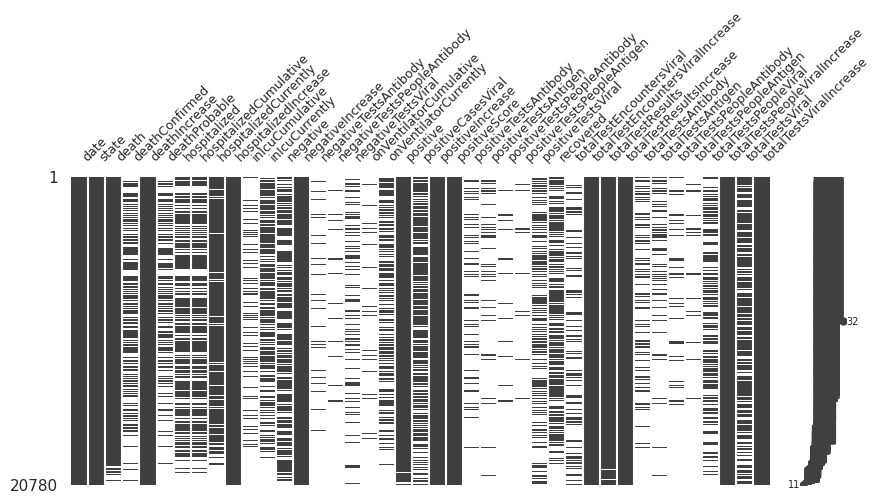


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
  [ ] NULOS: Revisar columnas con >30% de vacío: ['deathConfirmed', 'deathProbable', 'hospitalized', 'hospitalizedCumulative', 'inIcuCumulative', 'inIcuCurrently', 'negative', 'negativeTestsAntibody', 'negativeTestsPeopleAntibody', 'negativeTestsViral', 'onVentilatorCumulative', 'onVentilatorCurrently', 'positiveCasesViral', 'positiveTestsAntibody', 'positiveTestsAntigen', 'positiveTestsPeopleAntibody', 'positiveTestsPeopleAntigen', 'positiveTestsViral', 'recovered', 'totalTestEncountersViral', 'totalTestsAntibody', 'totalTestsAntigen', 'totalTestsPeopleAntibody', 'totalTestsPeopleAntigen', 'totalTestsPeopleViral', 'totalTestsViral']
  [ ] FORMATO: Convertir a datetime: ['date']
------------------------------------------------------------
  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.


In [5]:
# Para ver el estado actual de tus 15,861 filas:
radiografia_tecnica(df_data)

# Para ver qué deberías limpiar:
plan_accion_datos(df_data)

### Limpieza de datos

En este apartado aplicaremos diferentes métodos para la limpieza del dataset.

#### Comprobacion de nulos

Comprobamos cuantos nulos tiene nuestro dataset.

In [6]:
df_data.isnull().sum()

,0
date,0
state,0
death,850
deathConfirmed,11358
deathIncrease,0
deathProbable,13187
hospitalized,8398
hospitalizedCumulative,8398
hospitalizedCurrently,3441
hospitalizedIncrease,0


Con la función anterior comprobamos que tenemos varios valores nulos.

Acto seguido utilizamos `info` para comprobar cómo está construida la base de datos por detrás diciendonos el tipo de datos y si hay datos nulos entre otra información importante.

In [7]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              20780 non-null  object 
 1   state                             20780 non-null  object 
 2   death                             19930 non-null  float64
 3   deathConfirmed                    9422 non-null   float64
 4   deathIncrease                     20780 non-null  int64  
 5   deathProbable                     7593 non-null   float64
 6   hospitalized                      12382 non-null  float64
 7   hospitalizedCumulative            12382 non-null  float64
 8   hospitalizedCurrently             17339 non-null  float64
 9   hospitalizedIncrease              20780 non-null  int64  
 10  inIcuCumulative                   3789 non-null   float64
 11  inIcuCurrently                    11636 non-null  float64
 12  nega

Mostramos las 20 primeras filas con `head` para poder visualizar un pequeño porcentaje de los datos.



In [8]:
df_data.head(20)

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110
5,2021-03-07,CA,54124.0,NaN,258,NaN,NaN,NaN,4291.0,0,...,49646014.0,133186,NaN,NaN,NaN,NaN,NaN,0,49646014.0,133186
6,2021-03-07,CO,5989.0,5251.0,3,735.0,23904.0,23904.0,326.0,18,...,6415123.0,38163,435053.0,NaN,NaN,NaN,2616541.0,6107,NaN,0
7,2021-03-07,CT,7704.0,6327.0,0,1377.0,NaN,NaN,428.0,0,...,6520366.0,0,NaN,396680.0,NaN,NaN,NaN,0,6520366.0,0
8,2021-03-07,DC,1030.0,NaN,0,NaN,NaN,NaN,150.0,0,...,1261363.0,5726,NaN,NaN,NaN,NaN,441942.0,1149,NaN,0
9,2021-03-07,DE,1473.0,1337.0,9,136.0,NaN,NaN,104.0,0,...,1431942.0,5867,NaN,NaN,NaN,NaN,633424.0,1132,NaN,0


Hemos decidido modificar los campos `state` y `date` para que estuvieran correctamente formateados.

En el caso de `state` queriamos quitarle los espacios al principio y al final y asegurarnos que esten en mayúscula.

En el caso de `date` ya que estaba formateado como `object` lo hemos formateado de forma correcta en formato fecha.

In [9]:
df_data['state'] = df_data['state'].str.strip().str.upper()      # Elimina espacios sobrantes y transformamos a mayúsculas.

In [10]:
df_data['date'] = pd.to_datetime(df_data['date'])

Comprobacion de duplicados

Hemos comprobado que no habia datos duplicados.

In [11]:
df_data.duplicated().sum()

np.int64(0)

Detectamos un problema y es que habia muchos datos con `NaN`asi que hemos decidido que dichos datos los vamos a cambiar por 0 en vez de hacer la media y el promedio.

De momento como no sabemos si esos datos van a ser necesarios, decidimos que fuera asi porque antes de inventarnos los datos preferimos dejarlos a `0` para que no afectara tanto la falta de datos a la hora de los cálculos.

In [12]:
df_data = df_data.fillna(0)

In [13]:
df_data

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,0.0,0,0.0,1293.0,1293.0,33.0,0,...,1731628.0,0,0.0,0.0,0.0,0.0,0.0,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,0.0,0.0,119757.0,0.0,2323788.0,2347,0.0,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,0.0,0.0,0.0,481311.0,0.0,0,2736442.0,3380
3,2021-03-07,AS,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,2140.0,0,0.0,0.0,0.0,0.0,0.0,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,0.0,444089.0,0.0,3842945.0,14856,7908105.0,45110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20775,2020-01-17,WA,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0
20776,2020-01-16,WA,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0
20777,2020-01-15,WA,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0
20778,2020-01-14,WA,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0


#### Comprobación de cambios de formatos

Verificamos que los cambios de formato se hayan realizado correctamente con `dytpes`

In [14]:
df_data.dtypes

,0
date,datetime64[ns]
state,object
death,float64
deathConfirmed,float64
deathIncrease,int64
deathProbable,float64
hospitalized,float64
hospitalizedCumulative,float64
hospitalizedCurrently,float64
hospitalizedIncrease,int64


Hacemos mas comprobaciones de formatos de datos y de los datos.

In [15]:
df_data.info()
df_data.head()
df_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              20780 non-null  datetime64[ns]
 1   state                             20780 non-null  object        
 2   death                             20780 non-null  float64       
 3   deathConfirmed                    20780 non-null  float64       
 4   deathIncrease                     20780 non-null  int64         
 5   deathProbable                     20780 non-null  float64       
 6   hospitalized                      20780 non-null  float64       
 7   hospitalizedCumulative            20780 non-null  float64       
 8   hospitalizedCurrently             20780 non-null  float64       
 9   hospitalizedIncrease              20780 non-null  int64         
 10  inIcuCumulative                   20780 non-nu

Index(['date', 'state', 'death', 'deathConfirmed', 'deathIncrease',
       'deathProbable', 'hospitalized', 'hospitalizedCumulative',
       'hospitalizedCurrently', 'hospitalizedIncrease', 'inIcuCumulative',
       'inIcuCurrently', 'negative', 'negativeIncrease',
       'negativeTestsAntibody', 'negativeTestsPeopleAntibody',
       'negativeTestsViral', 'onVentilatorCumulative', 'onVentilatorCurrently',
       'positive', 'positiveCasesViral', 'positiveIncrease', 'positiveScore',
       'positiveTestsAntibody', 'positiveTestsAntigen',
       'positiveTestsPeopleAntibody', 'positiveTestsPeopleAntigen',
       'positiveTestsViral', 'recovered', 'totalTestEncountersViral',
       'totalTestEncountersViralIncrease', 'totalTestResults',
       'totalTestResultsIncrease', 'totalTestsAntibody', 'totalTestsAntigen',
       'totalTestsPeopleAntibody', 'totalTestsPeopleAntigen',
       'totalTestsPeopleViral', 'totalTestsPeopleViralIncrease',
       'totalTestsViral', 'totalTestsViralIncrease'

Utilizamos las funciones creadas anteriormente y tambien la tercera para comprobar y ver la diferencia despues de haber limpiado y tratado los datos.

La tercera función nos permite hacer esa comprobación.

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 20,780
  • Columnas: 41
  • Celdas totales: 851,980
  • Datos faltantes: 0 (0.00%)
  • Filas duplicadas: 0
  • Uso de memoria: 7.35 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
date,datetime64[ns],20780,0,0.00%,420,2.02%,2021-03-07 00:00:00
state,object,20780,0,0.00%,56,0.27%,AK
death,float64,20780,0,0.00%,7476,35.98%,305.000000
deathConfirmed,float64,20780,0,0.00%,5377,25.88%,0.000000
deathIncrease,int64,20780,0,0.00%,429,2.06%,0
deathProbable,float64,20780,0,0.00%,1392,6.70%,0.000000
hospitalized,float64,20780,0,0.00%,7572,36.44%,1293.000000
hospitalizedCumulative,float64,20780,0,0.00%,7572,36.44%,1293.000000
hospitalizedCurrently,float64,20780,0,0.00%,3885,18.70%,33.000000
hospitalizedIncrease,int64,20780,0,0.00%,566,2.72%,0


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,min,25%,50%,75%,max,std
date,20780,2020-09-02 18:13:30.779595776,2020-01-13 00:00:00,2020-06-02 00:00:00,2020-09-03 00:00:00,2020-12-05 00:00:00,2021-03-07 00:00:00,NaN
death,20780.0,3531.596824,0.0,118.0,982.0,4159.0,54124.0,6194.636505
deathConfirmed,20780.0,1709.464004,0.0,0.0,0.0,1921.0,21177.0,3370.488127
deathIncrease,20780.0,24.790712,-201.0,0.0,6.0,24.0,2559.0,60.162742
deathProbable,20780.0,152.478008,0.0,0.0,0.0,114.0,2594.0,382.08244
hospitalized,20780.0,5519.322666,0.0,0.0,462.0,6411.0,82237.0,10750.201894
hospitalizedCumulative,20780.0,5519.322666,0.0,0.0,462.0,6411.0,82237.0,10750.201894
hospitalizedCurrently,20780.0,993.427045,0.0,46.0,370.0,1051.0,22851.0,1933.09738
hospitalizedIncrease,20780.0,37.36078,-12257.0,0.0,0.0,36.0,16373.0,208.237151
inIcuCumulative,20780.0,352.678152,0.0,0.0,0.0,0.0,9263.0,1119.533486


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


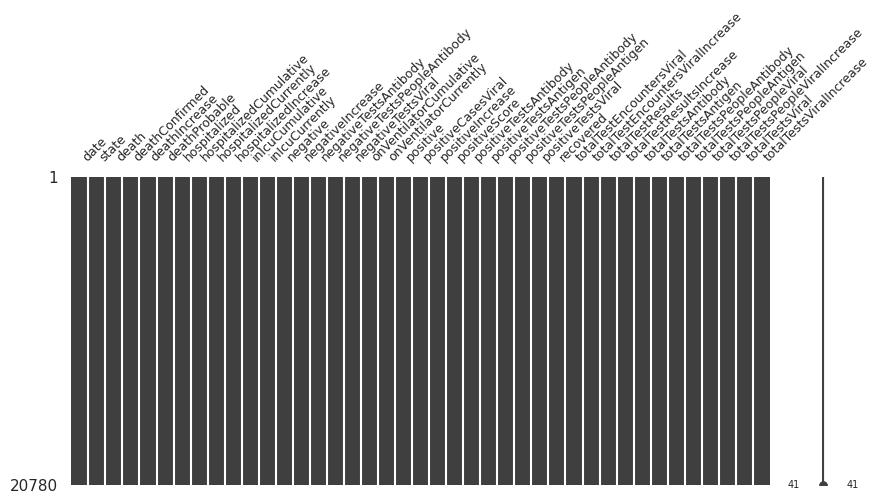


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
------------------------------------------------------------
  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.
             ⚖️ COMPARATIVA DE CALIDAD DE DATOS             


Métrica,Snapshot Inicial,Snapshot Final
Filas Totales,"20,780","20,780"
Columnas,41,41
Celdas con Nulos,"373,695",0
% Global de Nulos,43.86%,0.00%
Filas Duplicadas,0,0
Memoria (MB),8.36,7.35



✅ Se han depurado 0 filas en total.


In [16]:
# Para ver el estado actual de tus 15,861 filas:
radiografia_tecnica(df_data)

# Para ver qué deberías limpiar:
plan_accion_datos(df_data)

#Comparativa
comparativo_snapshot(df_data_raw, df_data)

Este bloque de código sirve para hacer una inspección rápida de los datos columna por columna, mostrándote cuáles son los 20 valores más frecuentes (y los errores más comunes) en cada una de ellas.

In [17]:
for col in df_data.columns:
    print(f"\n--- {col} ---")
    print(df_data[col].value_counts(dropna=False).head(20))


--- date ---
date
2020-03-16    56
2020-03-17    56
2020-03-18    56
2020-03-19    56
2020-03-20    56
2021-02-04    56
2021-02-05    56
2021-02-06    56
2021-02-07    56
2021-02-08    56
2021-02-09    56
2021-02-10    56
2021-02-11    56
2021-02-12    56
2021-02-13    56
2021-02-14    56
2021-02-15    56
2021-02-16    56
2021-02-17    56
2021-02-18    56
Name: count, dtype: int64

--- state ---
state
WA    420
MA    411
VA    406
FL    404
NJ    392
NE    387
IN    375
CT    373
RI    372
MI    372
WY    372
NY    371
VT    370
PA    370
TX    370
WI    370
HI    369
IL    369
NC    369
NH    369
Name: count, dtype: int64

--- death ---
death
0.0     1402
2.0      421
5.0      178
1.0      150
6.0      120
17.0     109
58.0     107
23.0      88
10.0      76
7.0       75
9.0       73
3.0       73
24.0      70
4.0       65
16.0      61
56.0      57
20.0      55
25.0      53
19.0      52
18.0      50
Name: count, dtype: int64

--- deathConfirmed ---
deathConfirmed
0.0       11391
2.0   

## REPRESENTACIÓN DE DATOS

### ¿Cómo evolucionó la pandemia en EEUU y qué olas se observan?

In [18]:
df_data.groupby("date")["state"].nunique().head()

,state
date,
2020-01-13,1
2020-01-14,1
2020-01-15,1
2020-01-16,1
2020-01-17,1


In [19]:
df_data.loc[
    df_data["date"] <= "2020-01-20",
    ["date", "state"]
].sort_values("date")

,date,state
20779,2020-01-13,WA
20778,2020-01-14,WA
20777,2020-01-15,WA
20776,2020-01-16,WA
20775,2020-01-17,WA
20774,2020-01-18,WA
20773,2020-01-19,WA
20772,2020-01-20,WA


In [20]:
first_reporting = (
    df_data.groupby("state")["date"]
    .min()
    .sort_values()
)

In [21]:
first_reporting.head(20)

,date
state,
WA,2020-01-13
MA,2020-01-22
VA,2020-01-27
FL,2020-01-29
NJ,2020-02-10
NE,2020-02-15
IN,2020-02-27
CT,2020-02-29
MI,2020-03-01


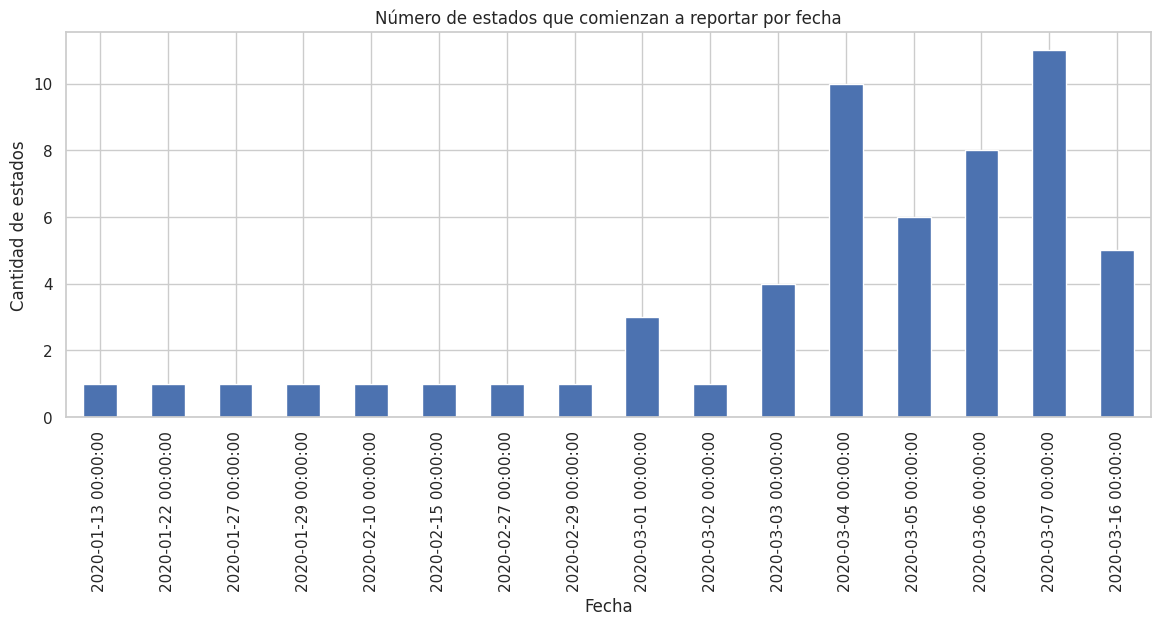

In [22]:
first_reporting.value_counts().sort_index().plot(
    kind="bar",
    figsize=(14,5)
)

plt.title(
    "Número de estados que comienzan a reportar por fecha"
)

plt.xlabel("Fecha")
plt.ylabel("Cantidad de estados")

plt.show()

In [23]:
usa_daily = (
    df_data
    .groupby("date")[
        ["positiveIncrease", "deathIncrease"]
    ]
    .sum()
    .reset_index()
)

usa_daily = usa_daily.sort_values(
    "date"
)

In [24]:
usa_daily.head()

,date,positiveIncrease,deathIncrease
0,2020-01-13,0,0
1,2020-01-14,0,0
2,2020-01-15,0,0
3,2020-01-16,0,0
4,2020-01-17,0,0


In [25]:
usa_daily["cases_7d"] = (
    usa_daily["positiveIncrease"]
    .rolling(window=7)
    .mean()
)

usa_daily["deaths_7d"] = (
    usa_daily["deathIncrease"]
    .rolling(window=7)
    .mean()
)

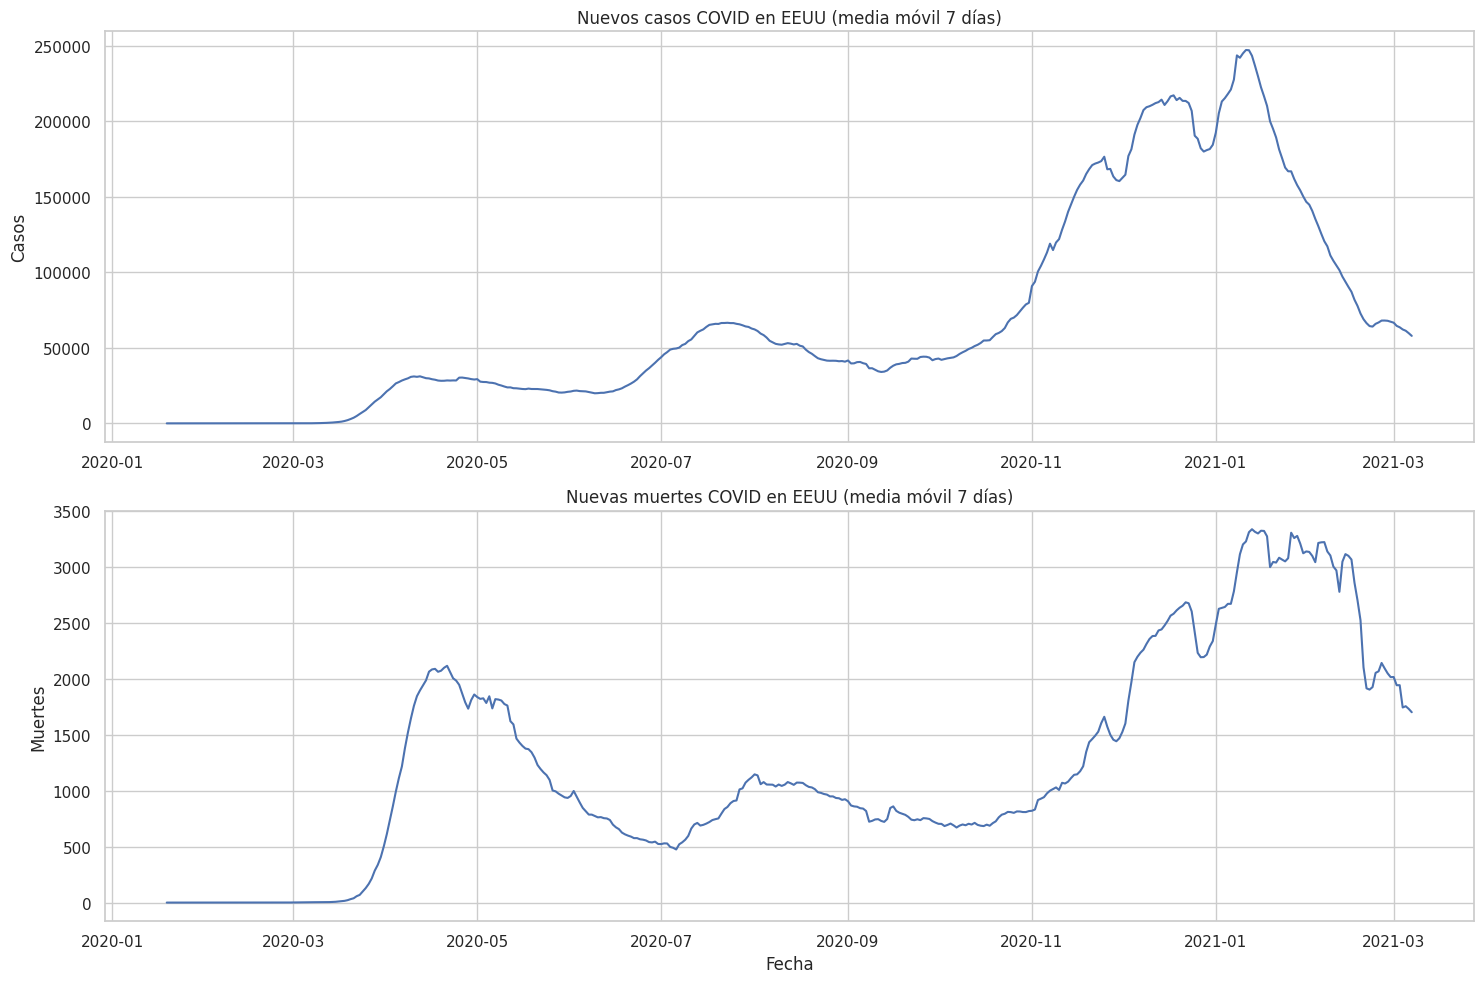

In [26]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(15,10)
)

# Casos
ax[0].plot(
    usa_daily["date"],
    usa_daily["cases_7d"]
)

ax[0].set_title(
    "Nuevos casos COVID en EEUU (media móvil 7 días)"
)

ax[0].set_ylabel("Casos")
ax[0].grid(True)

# Muertes
ax[1].plot(
    usa_daily["date"],
    usa_daily["deaths_7d"]
)

ax[1].set_title(
    "Nuevas muertes COVID en EEUU (media móvil 7 días)"
)

ax[1].set_ylabel("Muertes")
ax[1].set_xlabel("Fecha")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [27]:
#Visualización de fechas

df_data.groupby("date")["state"].nunique().head()

,state
date,
2020-01-13,1
2020-01-14,1
2020-01-15,1
2020-01-16,1
2020-01-17,1


Esto nos dice que al principio solo había un `estado con registros`.

In [28]:
#Qué estados tenían los primeros registros:

df_data.loc[
    df_data["date"] <= "2020-01-20",
    ["date", "state"]
].sort_values("date")

,date,state
20779,2020-01-13,WA
20778,2020-01-14,WA
20777,2020-01-15,WA
20776,2020-01-16,WA
20775,2020-01-17,WA
20774,2020-01-18,WA
20773,2020-01-19,WA
20772,2020-01-20,WA


Nos muestra el `estado` que primero tuvo registros en esos `primeros días`

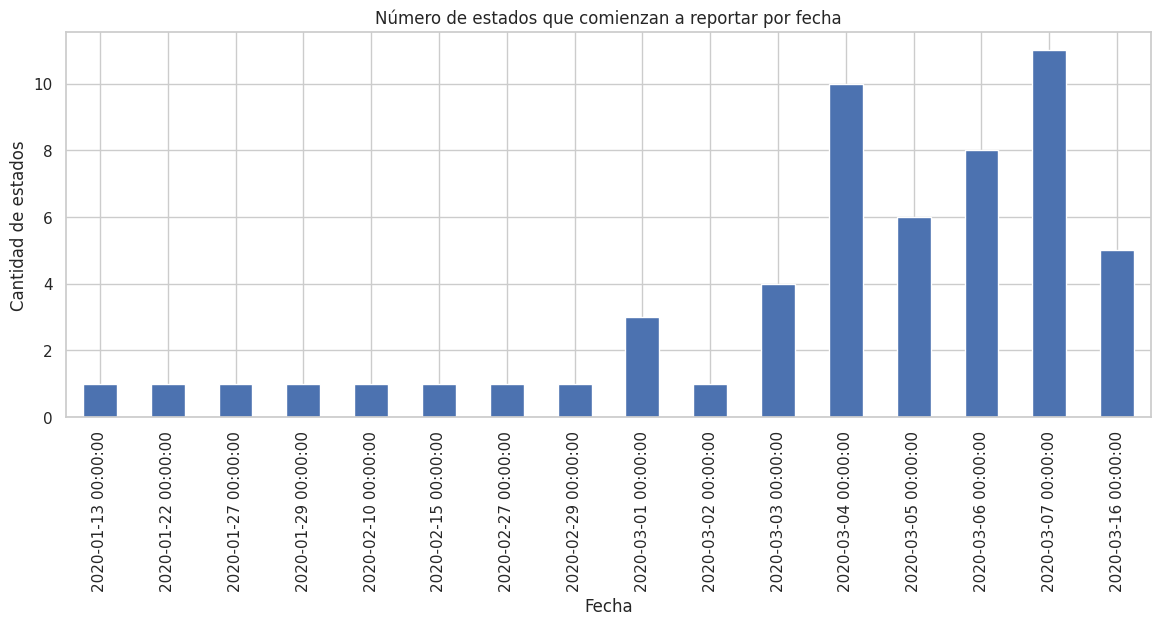

In [29]:
#Ranking temporal de estados:

first_reporting.value_counts().sort_index().plot(
    kind="bar",
    figsize=(14,5)
)

plt.title("Número de estados que comienzan a reportar por fecha")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de estados")

plt.show()

In [30]:
#Visualización de la primera fecha reportada por cada estado:

first_reporting_df = (
    first_reporting
    .reset_index()
)

first_reporting_df.columns = [
    "state",
    "first_report_date"
]

first_reporting_df.head(20)

,state,first_report_date
0,WA,2020-01-13
1,MA,2020-01-22
2,VA,2020-01-27
3,FL,2020-01-29
4,NJ,2020-02-10
5,NE,2020-02-15
6,IN,2020-02-27
7,CT,2020-02-29
8,MI,2020-03-01
9,RI,2020-03-01


In [31]:
#Agregar datos nacionales por día, sumar los estados por fecha

usa_daily = (
    df_data
    .groupby("date")[["positiveIncrease", "deathIncrease"]]
    .sum()
    .reset_index()
)

usa_daily = usa_daily.sort_values("date")

In [32]:
#Primeras fechas

usa_daily.head()

,date,positiveIncrease,deathIncrease
0,2020-01-13,0,0
1,2020-01-14,0,0
2,2020-01-15,0,0
3,2020-01-16,0,0
4,2020-01-17,0,0


In [33]:
#Últimos datos

usa_daily.tail()

,date,positiveIncrease,deathIncrease
415,2021-03-03,66836,2449
416,2021-03-04,65487,1743
417,2021-03-05,68787,2221
418,2021-03-06,60015,1680
419,2021-03-07,41835,842


In [34]:
usa_daily.shape

(420, 3)

In [35]:
print(type(usa_daily))


<class 'pandas.core.frame.DataFrame'>


In [36]:
usa_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              420 non-null    datetime64[ns]
 1   positiveIncrease  420 non-null    int64         
 2   deathIncrease     420 non-null    int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 10.0 KB


In [37]:
#Media móvil de 7 días

usa_daily["cases_7d"] = (
    usa_daily["positiveIncrease"]
    .rolling(window=7)
    .mean()
)

usa_daily["deaths_7d"] = (
    usa_daily["deathIncrease"]
    .rolling(window=7)
    .mean()
)


In [38]:
usa_daily.head(10)

,date,positiveIncrease,deathIncrease,cases_7d,deaths_7d
0,2020-01-13,0,0,NaN,NaN
1,2020-01-14,0,0,NaN,NaN
2,2020-01-15,0,0,NaN,NaN
3,2020-01-16,0,0,NaN,NaN
4,2020-01-17,0,0,NaN,NaN
5,2020-01-18,0,0,NaN,NaN
6,2020-01-19,1,0,0.142857,0.0
7,2020-01-20,0,0,0.142857,0.0
8,2020-01-21,1,0,0.285714,0.0
9,2020-01-22,0,0,0.285714,0.0


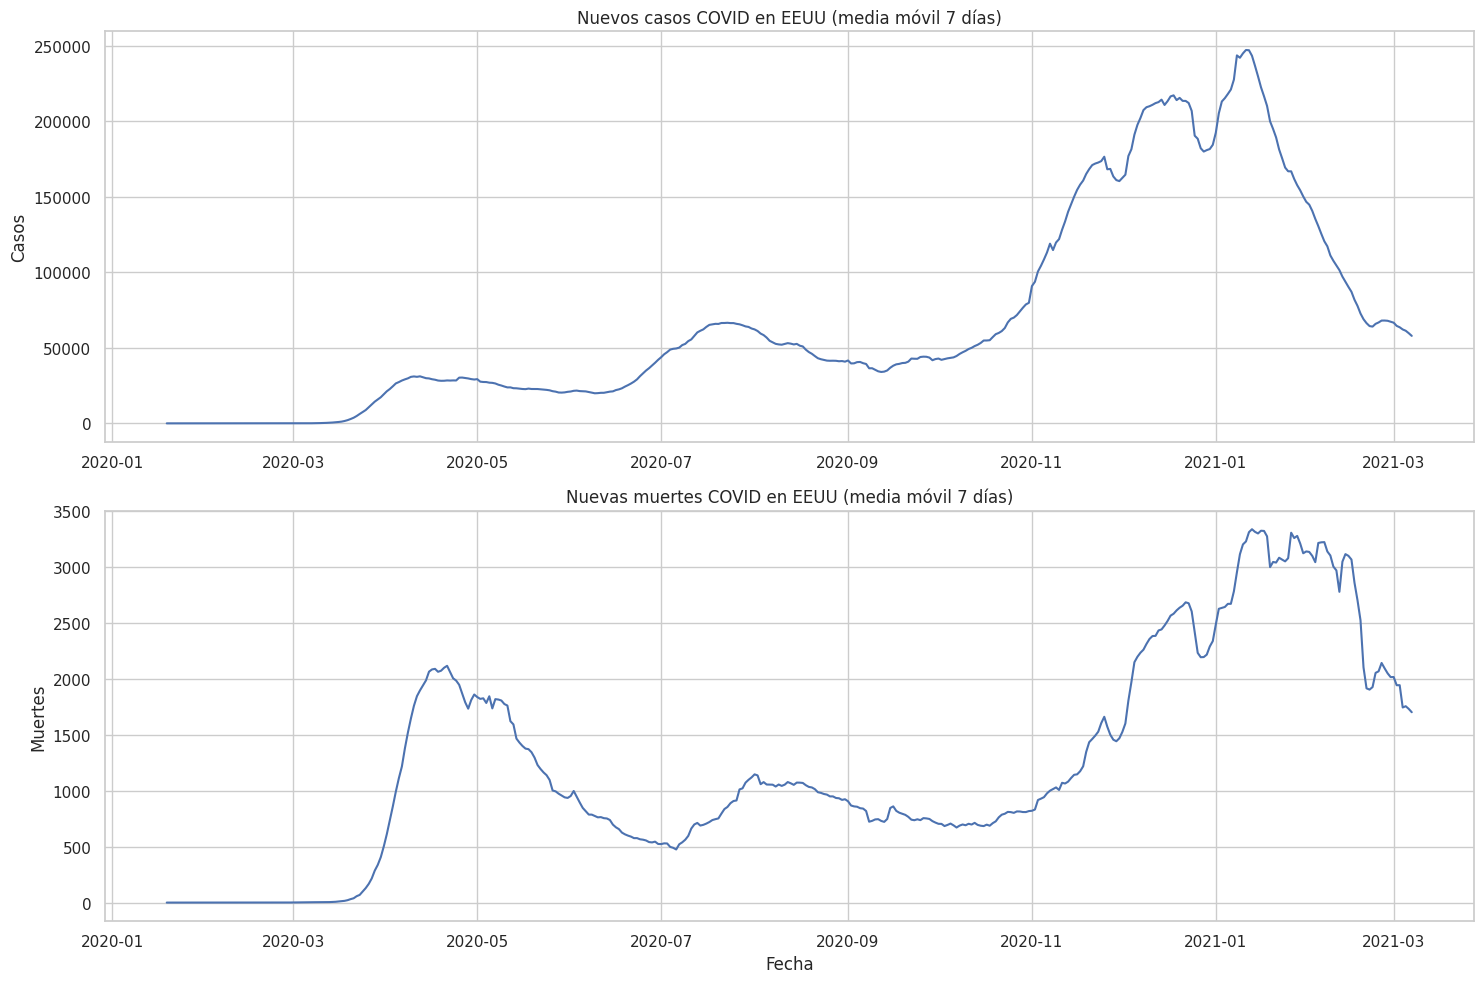

In [39]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(15,10)
)

# Casos
ax[0].plot(
    usa_daily["date"],
    usa_daily["cases_7d"]
)

ax[0].set_title(
    "Nuevos casos COVID en EEUU (media móvil 7 días)"
)

ax[0].set_ylabel("Casos")
ax[0].grid(True)

# Muertes
ax[1].plot(
    usa_daily["date"],
    usa_daily["deaths_7d"]
)

ax[1].set_title(
    "Nuevas muertes COVID en EEUU (media móvil 7 días)"
)

ax[1].set_ylabel("Muertes")
ax[1].set_xlabel("Fecha")
ax[1].grid(True)

plt.tight_layout()
plt.show()

El gráfico anterior muestra `las olas` que hubieron tanto de casos como de `muertes`

### ¿Todos los estados siguieron el mismo patrón temporal?

`Hipótesis:` Probablemente no.
Algunos estados tuvieron olas tempranas, otros tardías y algunos múltiples picos

In [40]:
#Crear casos diarios. Agregamos por fecha y estado:

state_daily = (
    df_data
    .groupby(["state", "date"])["positiveIncrease"]
    .sum()
    .reset_index()
)

In [41]:
state_daily.head()

,state,date,positiveIncrease
0,AK,2020-03-06,0
1,AK,2020-03-07,0
2,AK,2020-03-08,0
3,AK,2020-03-09,0
4,AK,2020-03-10,0


In [42]:
#Suavizar el ruido

state_daily["cases_7d"] = (
    state_daily
    .groupby("state")["positiveIncrease"]
    .transform(
        lambda x: x.rolling(7).mean()
    )
)

In [43]:
#Matriz para heatmap:

heatmap_data = state_daily.pivot(
    index="state",
    columns="date",
    values="cases_7d"
)

In [44]:
heatmap_data.shape


(56, 420)

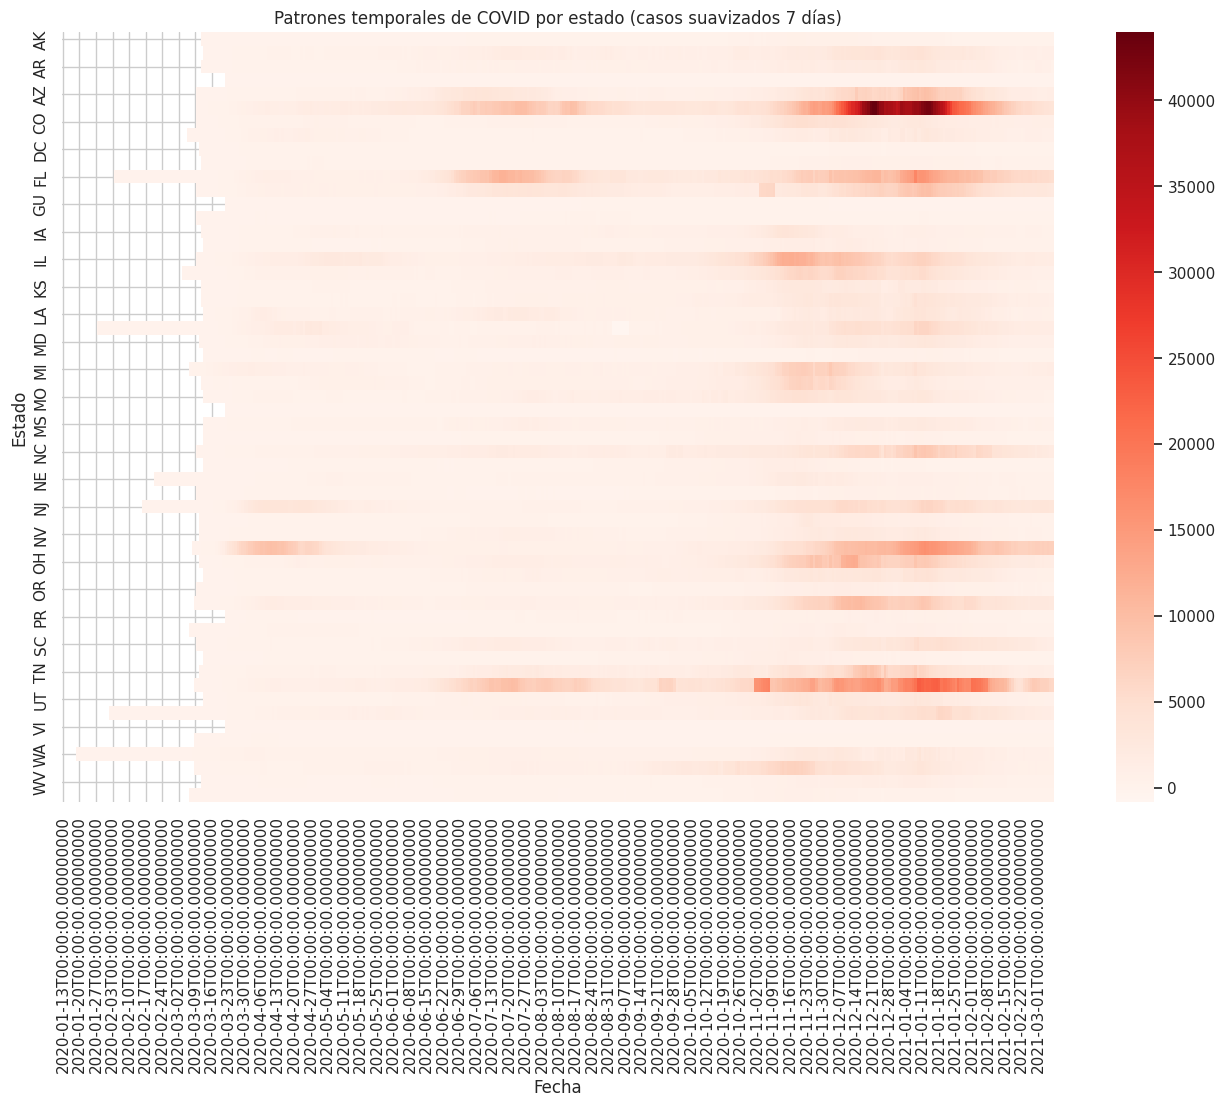

In [45]:
#Mostrar mapa:

plt.figure(figsize=(16,10))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    cbar=True
)

plt.title(
    "Patrones temporales de COVID por estado (casos suavizados 7 días)"
)

plt.xlabel("Fecha")
plt.ylabel("Estado")

plt.show()


Se observan `primeros picos` en los estados de `NY` posteriormente en `TN`, `DC`, y `AZ`. Se observa un `tercer rango` dónde `AZ`, `TN` y `DC` destacan.

No se observa `sincronización nacional`

In [46]:
#Estados con mayor pico de casos:

top_peaks = (
    state_daily
    .groupby("state")["cases_7d"]
    .max()
    .sort_values(ascending=False)
    .reset_index()
)

top_peaks.head(30)

,state,cases_7d
0,CA,43948.142857
1,TX,23043.571429
2,FL,17568.857143
3,NY,16334.571429
4,OH,12529.000000
5,IL,12384.000000
6,PA,10578.857143
7,AZ,9803.714286
8,GA,9778.285714
9,TN,9627.000000


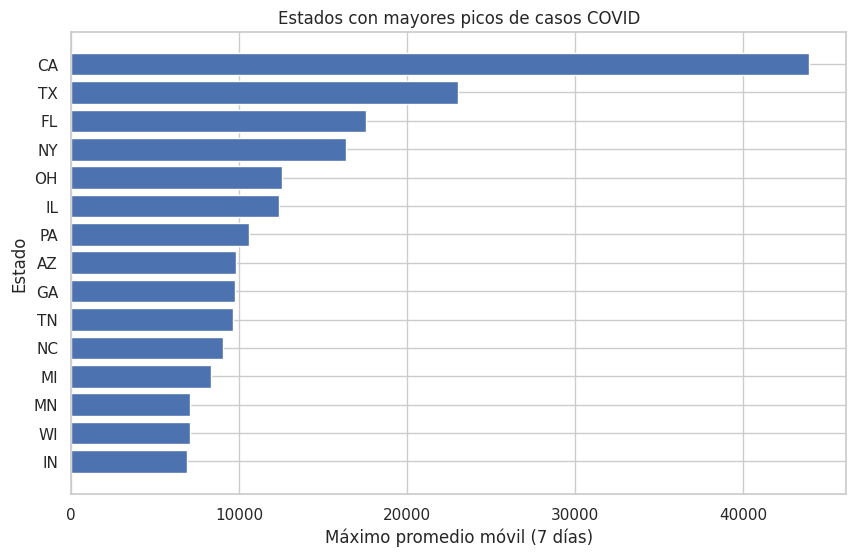

In [47]:
#Más claro:

plt.figure(figsize=(10,6))

top10 = top_peaks.head(15)

plt.barh(
    top10["state"],
    top10["cases_7d"]
)

plt.title("Estados con mayores picos de casos COVID")
plt.xlabel("Máximo promedio móvil (7 días)")
plt.ylabel("Estado")

plt.gca().invert_yaxis()

plt.show()

In [48]:
#Fechas de los picos

peak_dates = (
    state_daily.loc[
        state_daily.groupby("state")["cases_7d"].idxmax(),
        ["state", "date", "cases_7d"]
    ]
    .sort_values("cases_7d", ascending=False)
)

peak_dates.head(15)

,state,date,cases_7d
2119,CA,2020-12-22,43948.142857
17694,TX,2021-01-09,23043.571429
4017,FL,2021-01-08,17568.857143
14022,NY,2021-01-12,16334.571429
14360,OH,2020-12-13,12529.000000
6161,IL,2020-11-16,12384.000000
15468,PA,2020-12-16,10578.857143
1771,AZ,2021-01-12,9803.714286
4391,GA,2021-01-13,9778.285714
17302,TN,2020-12-18,9627.000000


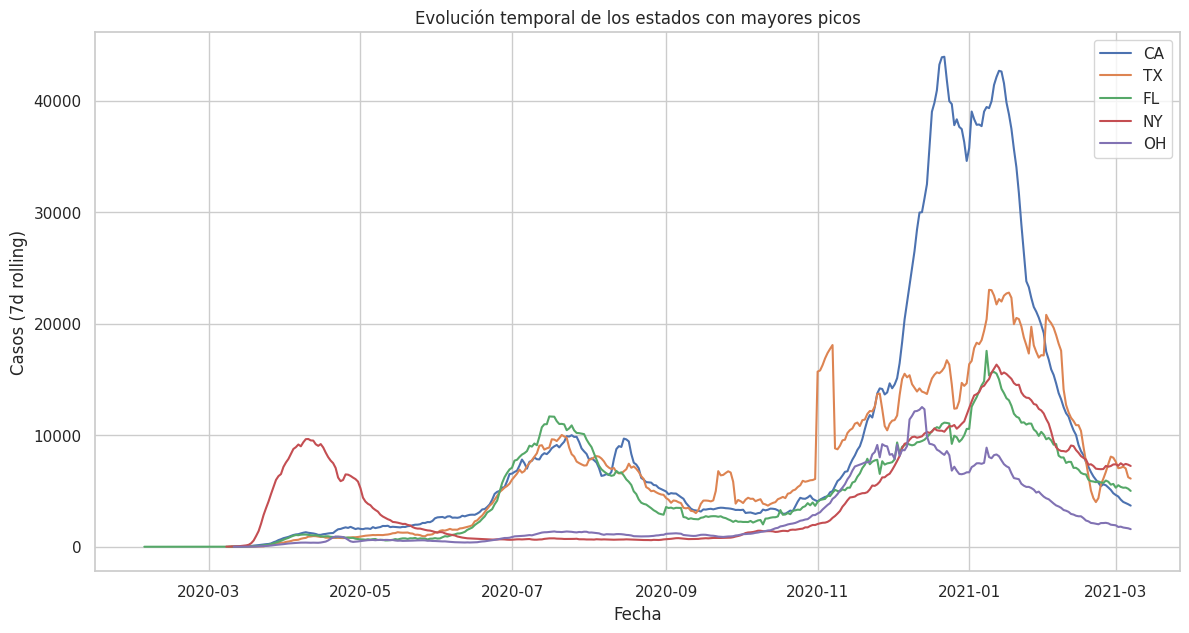

In [49]:
top_states = top_peaks.head(5)["state"]

plt.figure(figsize=(14,7))

for state in top_states:
    temp = state_daily[
        state_daily["state"] == state
    ]

    plt.plot(
        temp["date"],
        temp["cases_7d"],
        label=state
    )

plt.title("Evolución temporal de los estados con mayores picos")
plt.xlabel("Fecha")
plt.ylabel("Casos (7d rolling)")
plt.legend()

plt.grid(True)
plt.show()

### ¿Qué estados sufrieron los peores picos per cápita?

In [50]:
#Diccionario de población:

state_population = {
    'AL': 4903185, 'AK': 731545, 'AZ': 7278717,
    'AR': 3017804, 'CA': 39512223, 'CO': 5758736,
    'CT': 3565287, 'DE': 973764, 'FL': 21477737,
    'GA': 10617423, 'HI': 1415872, 'ID': 1787065,
    'IL': 12671821, 'IN': 6732219, 'IA': 3155070,
    'KS': 2913314, 'KY': 4467673, 'LA': 4648794,
    'ME': 1344212, 'MD': 6045680, 'MA': 6892503,
    'MI': 9986857, 'MN': 5639632, 'MS': 2976149,
    'MO': 6137428, 'MT': 1068778, 'NE': 1934408,
    'NV': 3080156, 'NH': 1359711, 'NJ': 8882190,
    'NM': 2096829, 'NY': 19453561, 'NC': 10488084,
    'ND': 762062, 'OH': 11689100, 'OK': 3956971,
    'OR': 4217737, 'PA': 12801989, 'RI': 1059361,
    'SC': 5148714, 'SD': 884659, 'TN': 6833174,
    'TX': 28995881, 'UT': 3205958, 'VT': 623989,
    'VA': 8535519, 'WA': 7614893, 'WV': 1792147,
    'WI': 5822434, 'WY': 578759, 'DC': 705749
}


In [51]:
#Añadimos población total:

state_daily["population"] = (
    state_daily["state"]
    .map(state_population)
)


In [52]:
state_daily[
    ["state", "population"]
].head()

,state,population
0,AK,731545.0
1,AK,731545.0
2,AK,731545.0
3,AK,731545.0
4,AK,731545.0


In [53]:
#Casos por cápita:

state_daily["cases_per_100k"] = (
    state_daily["positiveIncrease"]
    / state_daily["population"]
) * 100000

In [54]:
state_daily["cases_per_100k_7d"] = (
    state_daily
    .groupby("state")["cases_per_100k"]
    .transform(
        lambda x: x.rolling(7).mean()
    )
)

In [55]:
#Peor pico per cápita:

worst_peaks = (
    state_daily
    .groupby("state")["cases_per_100k_7d"]
    .max()
    .sort_values(ascending=False)
    .reset_index()
)

worst_peaks.head(15)

,state,cases_per_100k_7d
0,ND,190.610663
1,SD,164.809265
2,WY,153.974773
3,TN,140.886212
4,AZ,134.690142
5,NM,127.362385
6,RI,125.331618
7,MN,125.036021
8,NE,123.618477
9,IA,121.079496


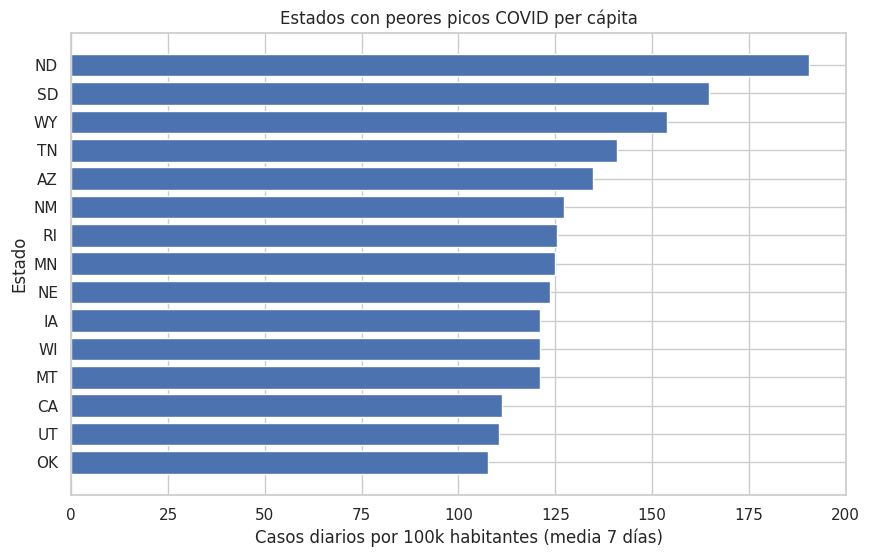

In [56]:
#Visualización:

plt.figure(figsize=(10,6))

top15 = worst_peaks.head(15)

plt.barh(
    top15["state"],
    top15["cases_per_100k_7d"]
)

plt.title(
    "Estados con peores picos COVID per cápita"
)

plt.xlabel(
    "Casos diarios por 100k habitantes (media 7 días)"
)

plt.ylabel("Estado")

plt.gca().invert_yaxis()

plt.show()


In [57]:
state_daily[
    state_daily["population"].isna()
]["state"].unique()

array(['AS', 'GU', 'MP', 'PR', 'VI'], dtype=object)

In [58]:
#Eliminamos estados sin población conocida:

state_daily_clean = state_daily.dropna(
    subset=["population"]
)

In [59]:
peak_per_capita = (
    state_daily_clean.loc[
        state_daily_clean.groupby("state")[
            "cases_per_100k_7d"
        ].idxmax(),
        [
            "state",
            "date",
            "cases_per_100k_7d"
        ]
    ]
    .sort_values(
        "cases_per_100k_7d",
        ascending=False
    )
)

peak_per_capita.head(15)

,state,date,cases_per_100k_7d
11712,ND,2020-11-18,190.610663
16900,SD,2020-11-14,164.809265
20675,WY,2020-11-23,153.974773
17302,TN,2020-12-18,140.886212
1771,AZ,2021-01-12,134.690142
13233,NM,2020-11-23,127.362385
16190,RI,2020-12-09,125.331618
9524,MN,2020-11-20,125.036021
12102,NE,2020-11-21,123.618477
5425,IA,2020-11-15,121.079496


In [60]:
#Añadir territorios faltantes:

state_population.update({
    'PR': 3193694,
    'GU': 168775,
    'VI': 104578,
    'AS': 55197,
    'MP': 57559
})

In [61]:
state_daily["population"] = (
    state_daily["state"]
    .map(state_population)
)

In [62]:
state_daily[
    state_daily["population"].isna()
]["state"].unique()

array([], dtype=object)

In [63]:
state_daily["cases_per_100k"] = (
    state_daily["positiveIncrease"]
    / state_daily["population"]
) * 100000

In [64]:
state_daily["cases_per_100k_7d"] = (
    state_daily
    .groupby("state")["cases_per_100k"]
    .transform(
        lambda x: x.rolling(7).mean()
    )
)

In [65]:
peak_per_capita = (
    state_daily.loc[
        state_daily.groupby("state")[
            "cases_per_100k_7d"
        ].idxmax(),
        [
            "state",
            "date",
            "cases_per_100k_7d"
        ]
    ]
    .sort_values(
        "cases_per_100k_7d",
        ascending=False
    )
)

peak_per_capita.head(15)

,state,date,cases_per_100k_7d
11712,ND,2020-11-18,190.610663
16900,SD,2020-11-14,164.809265
20675,WY,2020-11-23,153.974773
17302,TN,2020-12-18,140.886212
1771,AZ,2021-01-12,134.690142
13233,NM,2020-11-23,127.362385
16190,RI,2020-12-09,125.331618
9524,MN,2020-11-20,125.036021
12102,NE,2020-11-21,123.618477
5425,IA,2020-11-15,121.079496


### ¿Hubo diferencias regionales claras?

`La hipótesis`:

El `COVID` no golpeó igual ni al mismo tiempo en todas las regiones.

Por ejemplo:

`Northeast` → primera ola fuerte (`NY, NJ`)
`South` → olas posteriores
`Midwest` → gran ola otoño/invierno
`West` → más gradual

In [66]:
#Asignar cada estado a una región:

state_region = {
    # Northeast
    'CT':'Northeast','ME':'Northeast',
    'MA':'Northeast','NH':'Northeast',
    'RI':'Northeast','VT':'Northeast',
    'NJ':'Northeast','NY':'Northeast',
    'PA':'Northeast',

    # Midwest
    'IL':'Midwest','IN':'Midwest',
    'MI':'Midwest','OH':'Midwest',
    'WI':'Midwest','IA':'Midwest',
    'KS':'Midwest','MN':'Midwest',
    'MO':'Midwest','NE':'Midwest',
    'ND':'Midwest','SD':'Midwest',

    # South
    'DE':'South','FL':'South',
    'GA':'South','MD':'South',
    'NC':'South','SC':'South',
    'VA':'South','DC':'South',
    'WV':'South','AL':'South',
    'KY':'South','MS':'South',
    'TN':'South','AR':'South',
    'LA':'South','OK':'South',
    'TX':'South',

    # West
    'AZ':'West','CO':'West',
    'ID':'West','MT':'West',
    'NV':'West','NM':'West',
    'UT':'West','WY':'West',
    'AK':'West','CA':'West',
    'HI':'West','OR':'West',
    'WA':'West'
}

In [67]:
state_daily["region"] = (
    state_daily["state"]
    .map(state_region)
)

In [68]:
state_daily[
    ["state", "region"]
].head()

,state,region
0,AK,West
1,AK,West
2,AK,West
3,AK,West
4,AK,West


In [69]:
state_daily[
    state_daily["region"].isna()
]["state"].unique()

array(['AS', 'GU', 'MP', 'PR', 'VI'], dtype=object)

In [70]:
state_region_df = state_daily.dropna(
    subset=["region"]
)

In [71]:
regional_daily = (
    state_region_df
    .groupby(["date", "region"])
    ["positiveIncrease"]
    .sum()
    .reset_index()
)

In [72]:
regional_daily["cases_7d"] = (
    regional_daily
    .groupby("region")["positiveIncrease"]
    .transform(
        lambda x: x.rolling(7).mean()
    )
)

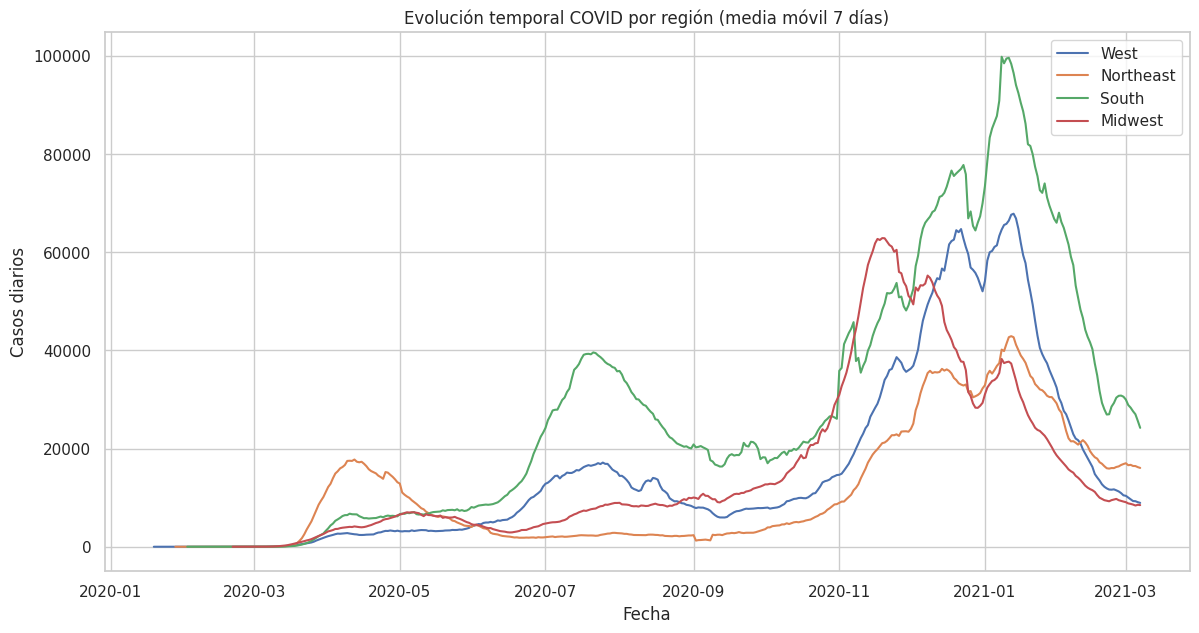

In [73]:
plt.figure(figsize=(14,7))

for region in regional_daily["region"].unique():

    temp = regional_daily[
        regional_daily["region"] == region
    ]

    plt.plot(
        temp["date"],
        temp["cases_7d"],
        label=region
    )

plt.title(
    "Evolución temporal COVID por región (media móvil 7 días)"
)

plt.xlabel("Fecha")
plt.ylabel("Casos diarios")
plt.legend()

plt.grid(True)
plt.show()

**¿Quién tuvo la primera gran ola?**
`Northeast entre 2020-03 y 2020-05`

**¿Qué región tuvo el pico más grande?**
`South entre 2020-11 y 2021-01`

**¿Hubo sincronización?**


Interpretación de la Pregunta 4

¿Hubo diferencias regionales claras?

La respuesta es:

Sí, muy claras, tanto en timing como en intensidad.

1.  `Northeast` → primera gran ola (`primavera 2020`)

La `línea naranja` muestra un pico fuerte y temprano alrededor de:

*   `abril–mayo 2020`

Esto encaja con:

*   Nueva York
*   Nueva Jersey
*   Massachusetts

Interpretación:

*   El `Northeast` fue el primer gran epicentro de `COVID en EEUU`.

Insight fuerte:

Mientras otras `regiones` aún tenían baja incidencia, el `Northeast` ya estaba sufriendo una ola importante.

2. `South` → olas tempranas y la más fuerte del país

La `línea verde` domina claramente.

Se ve:

*   un gran pico en `verano 2020`
*   una explosión enorme `invierno 2020–21`

Con un máximo cercano a:

*   100k casos diarios

Interpretación:

El `South` experimentó las olas más intensas en términos absolutos.

Esto puede estar influido por:

*   `Texas + Florida` + gran población regional.

3. `Midwest` → ola muy intensa otoño/invierno

La `línea roja` muestra algo muy interesante:

*   un crecimiento explosivo en `noviembre–diciembre 2020`.
*   Casi parece un “shock” epidemiológico.

Interpretación:

El `Midwest` tuvo una ola tardía pero muy pronunciada.

4. `West` → crecimiento más gradual y tardío

La `línea azul`:

*   menos explosiva al principio
*   gran subida hacia `invierno 2020–21`

Interpretación:

El `West` parece experimentar una evolución más gradual, aunque alcanza máximos elevados en `enero de 2021`.

5. ¿Hubo sincronización nacional?

Sí, pero parcial.

A `finales de 2020` ocurre algo muy claro:

*   todas las `regiones` aumentan simultáneamente.

Eso sugiere:

*   una ola nacional sincronizada durante `invierno 2020–21`.

Es probablemente el `insight` más fuerte del gráfico.

**Resumen**

Se observan diferencias regionales importantes en la evolución temporal del `COVID-19`.
El `Northeast` presenta una ola temprana e intensa durante `primavera de 2020`, siendo el primer epicentro nacional.
Posteriormente, `South` y `Midwest` muestran aumentos más pronunciados, destacando una ola sincronizada entre regiones durante el `invierno 2020–2021`. Aunque todas las regiones convergen temporalmente en el gran pico invernal, el timing y magnitud de las olas no fueron homogéneos.

### ¿Existe relación entre volumen de testing y detección de casos?

In [74]:
df_data["positivity_rate"] = (
    df_data["positiveIncrease"]
    / df_data["totalTestResultsIncrease"]
)

In [75]:
df_data = df_data[
    (df_data["positivity_rate"] >= 0) &
    (df_data["positivity_rate"] <= 1)
]

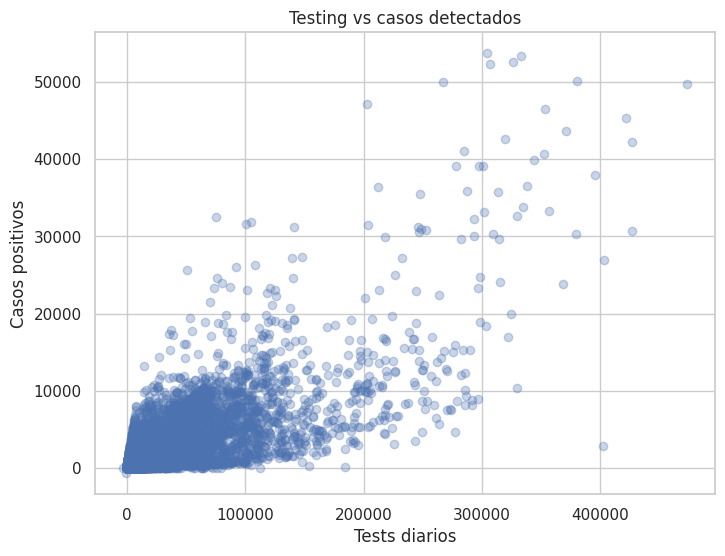

In [76]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_data["totalTestResultsIncrease"],
    df_data["positiveIncrease"],
    alpha=0.3
)

plt.title(
    "Testing vs casos detectados"
)

plt.xlabel("Tests diarios")
plt.ylabel("Casos positivos")

plt.grid(True)
plt.show()

In [77]:
usa_testing = (
    df_data.groupby("date")[
        ["positiveIncrease",
         "totalTestResultsIncrease"]
    ]
    .sum()
    .reset_index()
)

In [78]:
usa_testing["positivity_rate"] = (
    usa_testing["positiveIncrease"]
    / usa_testing["totalTestResultsIncrease"]
)

In [79]:
usa_testing["positivity_7d"] = (
    usa_testing["positivity_rate"]
    .rolling(7)
    .mean()
)

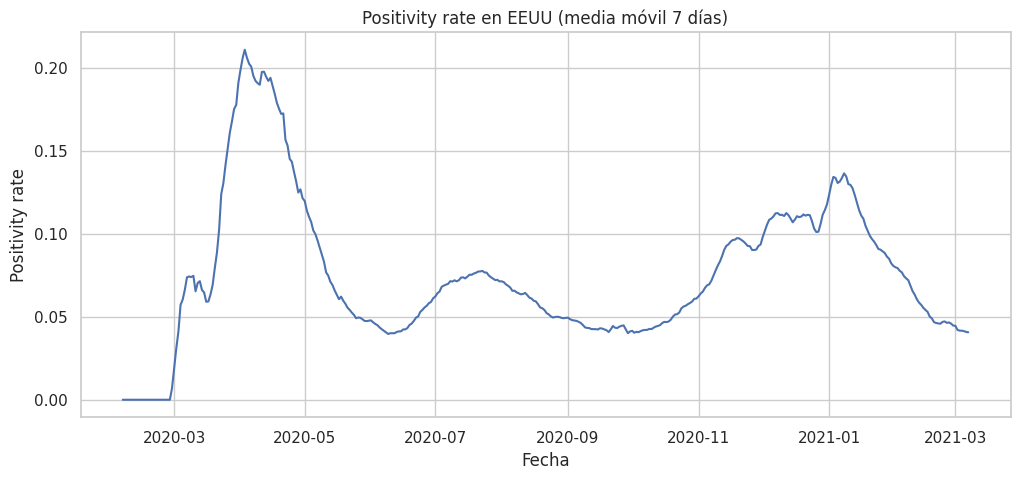

In [80]:
plt.figure(figsize=(12,5))

plt.plot(
    usa_testing["date"],
    usa_testing["positivity_7d"]
)

plt.title(
    "Positivity rate en EEUU (media móvil 7 días)"
)

plt.xlabel("Fecha")
plt.ylabel("Positivity rate")

plt.grid(True)
plt.show()

*`Observar`* positividad alta (posible falta de testing)

`Positividad baja` (mejor capacidad diagnóstica)

`Picos de positividad` <> necesariamente más contagios reales, puede haber menos test

### ¿Qué estados mantuvieron una positividad peligrosamente alta?

/tmp/ipykernel_562/1723464508.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['year_month'] = df_data['date'].dt.strftime('%Y-%m')


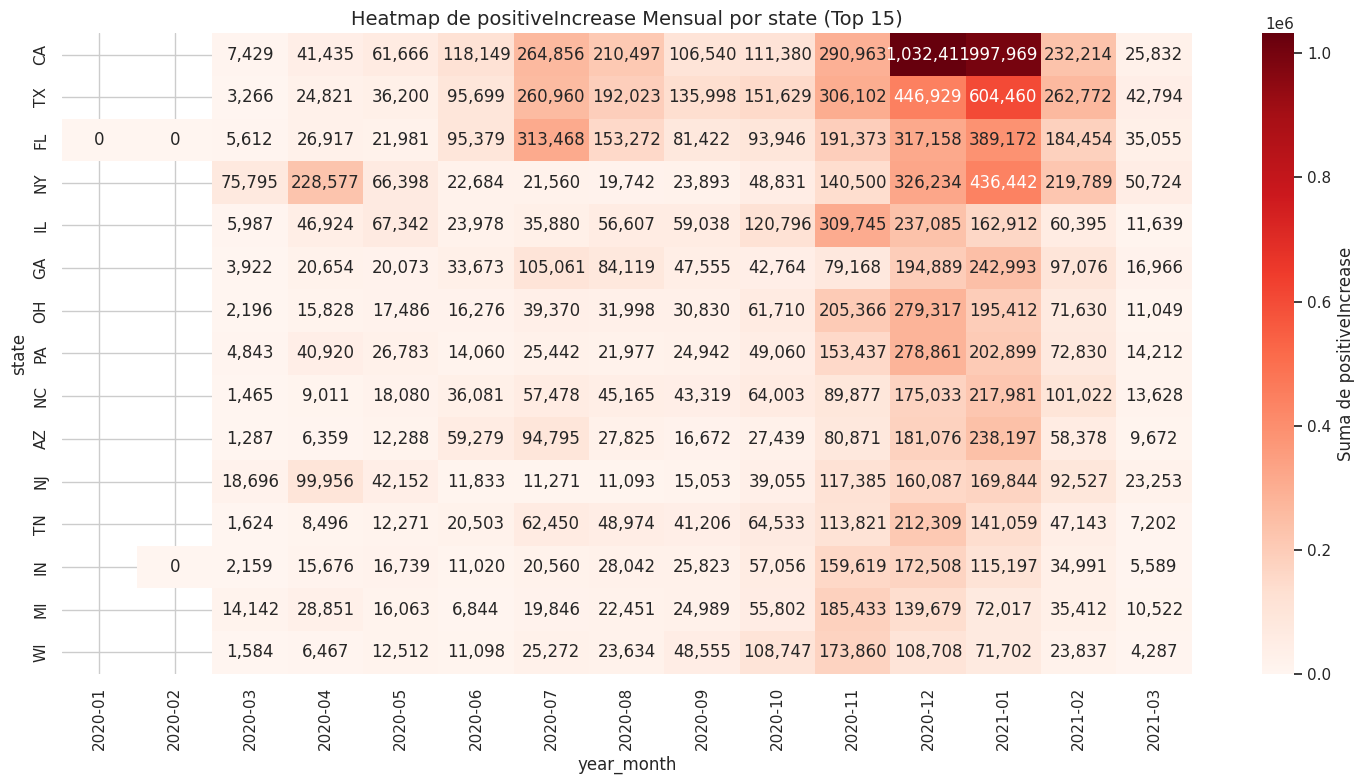

In [81]:
# Asegurar el formato de fecha y extraer año-mes usando operaciones nativas de pandas
df_data['year_month'] = df_data['date'].dt.strftime('%Y-%m')

# Agrupar estrictamente por las columnas reales del dataset: 'state' y la nueva 'year_month'
# Sumamos 'positiveIncrease' tal cual viene en el archivo original
grouped = df_data.groupby(['state', 'year_month'])['positiveIncrease'].sum().reset_index()

# Para que el heatmap sea legible y no sature la memoria con los 56 estados/territorios,
# filtramos por los 15 estados con mayor volumen total de 'positiveIncrease' acumulado
top_15_states = grouped.groupby('state')['positiveIncrease'].sum().sort_values(ascending=False).head(15).index

grouped_filtered = grouped[grouped['state'].isin(top_15_states)]

# Pivotar usando estrictamente los nombres de las columnas
heatmap_data = grouped_filtered.pivot(index='state', columns='year_month', values='positiveIncrease')

# Ordenar los estados de mayor a menor según el volumen para mejorar la legibilidad
heatmap_data = heatmap_data.loc[top_15_states]

# Crear el gráfico sin alterar o inventar datos
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, fmt=",.0f", cmap="Reds", cbar_kws={'label': 'Suma de positiveIncrease'})
plt.title('Heatmap de positiveIncrease Mensual por state (Top 15)', fontsize=14)
plt.xlabel('year_month')
plt.ylabel('state')
plt.tight_layout()

# Guardar la imagen exacta
plt.savefig('heatmap_real_positiveIncrease.png', dpi=150)
plt.show()

###¿Las hospitalizaciones predicen las muertes?

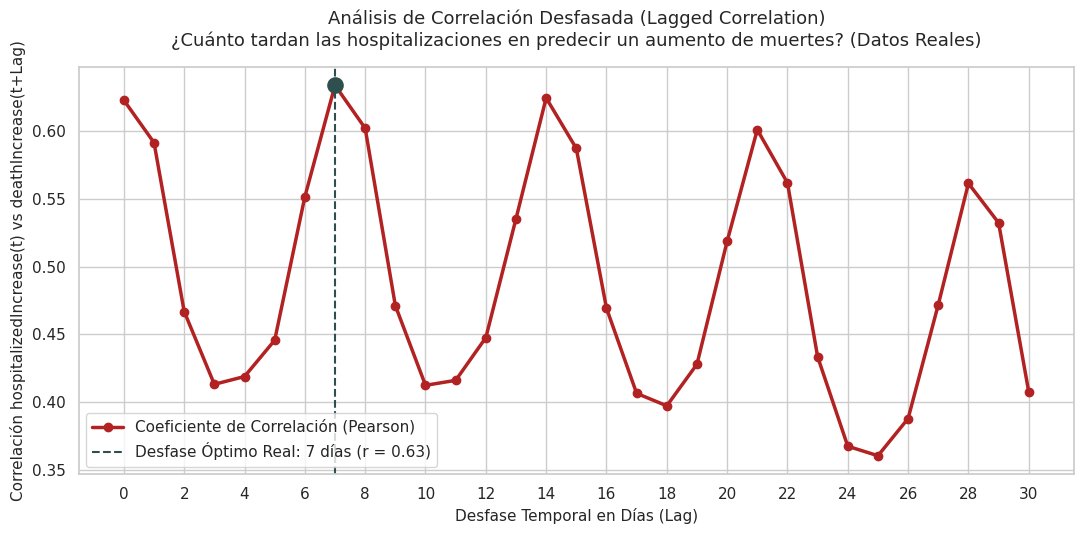

In [82]:
#. Agrupar a nivel nacional usando las columnas exactas del CSV
national_ts = df_data.groupby('date')[['hospitalizedIncrease', 'deathIncrease']].sum().sort_index()

#. Calcular la correlación desfasada (Lagged Correlation) de 0 a 30 días
lags = range(0, 31)
correlations = []

for lag in lags:
    # Correlación de hospitalizedIncrease en el momento (t) vs deathIncrease en el momento (t + lag)
    corr = national_ts['hospitalizedIncrease'].corr(national_ts['deathIncrease'].shift(-lag))
    correlations.append(corr)

#. Identificar el desfase con la correlación más alta
optimal_lag = lags[np.argmax(correlations)]
max_corr = max(correlations)

#. Crear el gráfico optimizado para visualizar en Colab
plt.figure(figsize=(11, 5.5))
sns.set_theme(style="whitegrid")

# Dibujar la curva de correlación
plt.plot(lags, correlations, marker='o', color='#b22222', linewidth=2.5, markersize=6,
         label='Coeficiente de Correlación (Pearson)')

# Dibujar la línea vertical en el punto de máxima predicción (Lag 7)
plt.axvline(x=optimal_lag, color='#2f4f4f', linestyle='--', linewidth=1.5,
            label=f'Desfase Óptimo Real: {optimal_lag} días (r = {max_corr:.2f})')
plt.scatter(optimal_lag, max_corr, color='#2f4f4f', s=120, zorder=5)

# Títulos y nombres de los ejes usando los nombres reales del dataset
plt.title('Análisis de Correlación Desfasada (Lagged Correlation)\n¿Cuánto tardan las hospitalizaciones en predecir un aumento de muertes? (Datos Reales)', fontsize=13, pad=15)
plt.xlabel('Desfase Temporal en Días (Lag)', fontsize=11)
plt.ylabel('Correlación hospitalizedIncrease(t) vs deathIncrease(t+Lag)', fontsize=11)
plt.xticks(range(0, 31, 2))
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()

# Mostrar directamente el gráfico debajo de la celda de Colab
plt.show()

### ¿La letalidad disminuyó con el tiempo?

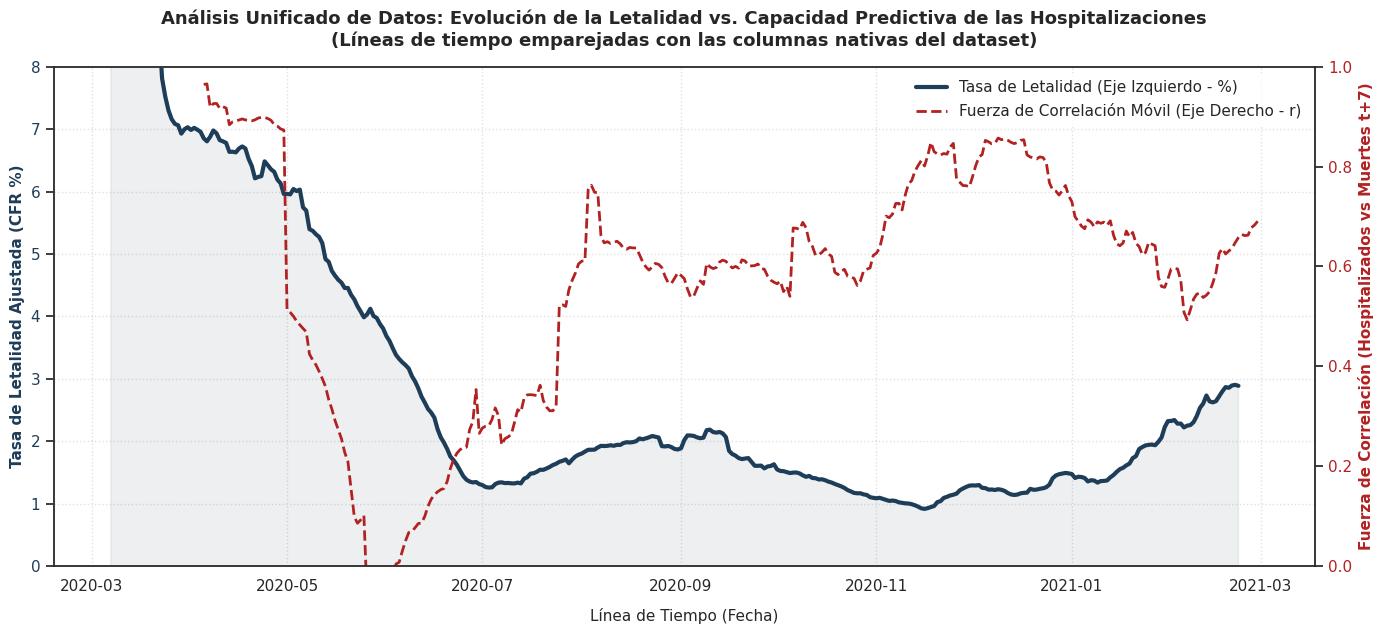

In [83]:
# Agrupar datos diarios a nivel nacional (ordenados cronológicamente)
df_daily = df_data.groupby('date')[['positiveIncrease', 'deathIncrease', 'hospitalizedIncrease']].sum().sort_index()

# ==========================================
# MEDICIÓN 1: Letalidad Diaria Ajustada (CFR)
# ==========================================
# Aplicamos el desfase óptimo de 7 días descubierto en los análisis previos
df_daily['death_lagged_7'] = df_daily['deathIncrease'].shift(-7)

# Calculamos el CFR diario y aplicamos una media móvil de 14 días para eliminar el "ruido" de los fines de semana
df_daily['CFR_diario'] = (df_daily['death_lagged_7'] / df_daily['positiveIncrease']) * 100
df_daily['CFR_suavizado'] = df_daily['CFR_diario'].rolling(window=14, center=True).mean()

# ==========================================
# MEDICIÓN 2: Correlación Móvil (Rolling Correlation)
# ==========================================
# Para ver cómo evoluciona la relación Hospitalizaciones vs Muertes a lo largo del tiempo,
# calculamos una correlación móvil con una ventana de 60 días usando el desfase de 7 días.
df_daily['Corr_Movil'] = df_daily['hospitalizedIncrease'].rolling(window=60).corr(df_daily['death_lagged_7'])

# ==========================================
# RENDERIZADO: Un solo gráfico, dos líneas, dos ejes Y
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 6.5))
sns.set_theme(style="white") # Fondo limpio para distinguir ejes

# --- LÍNEA 1: Tasa de Letalidad (Eje Y Izquierdo) ---
color_cfr = '#1e3d59'
ax1.set_xlabel('Línea de Tiempo (Fecha)', fontsize=11, labelpad=10)
ax1.set_ylabel('Tasa de Letalidad Ajustada (CFR %)', color=color_cfr, fontsize=11, fontweight='bold')

line1 = ax1.plot(df_daily.index, df_daily['CFR_suavizado'], color=color_cfr, linewidth=3,
                 label='Tasa de Letalidad (Eje Izquierdo - %)')
ax1.fill_between(df_daily.index, df_daily['CFR_suavizado'], color=color_cfr, alpha=0.08)
ax1.tick_params(axis='y', labelcolor=color_cfr)
ax1.set_ylim(0, 8)

# --- LÍNEA 2: Fuerza de la Correlación (Eje Y Derecho) ---
ax2 = ax1.twinx() # Crear el segundo eje Y que comparte el mismo eje X
color_corr = '#b22222'
ax2.set_ylabel('Fuerza de Correlación (Hospitalizados vs Muertes t+7)', color=color_corr, fontsize=11, fontweight='bold')

line2 = ax2.plot(df_daily.index, df_daily['Corr_Movil'], color=color_corr, linewidth=2, linestyle='--',
                 label='Fuerza de Correlación Móvil (Eje Derecho - r)')
ax2.tick_params(axis='y', labelcolor=color_corr)
ax2.set_ylim(0, 1.0) # La correlación máxima posible es 1

# Enmarcar el gráfico con una cuadrícula sutil orientada al eje principal
ax1.grid(True, linestyle=':', alpha=0.6)

# Combinar las leyendas de ambos ejes en una sola caja clara
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Título del gráfico
plt.title('Análisis Unificado de Datos: Evolución de la Letalidad vs. Capacidad Predictiva de las Hospitalizaciones\n(Líneas de tiempo emparejadas con las columnas nativas del dataset)', fontsize=13, pad=15, fontweight='bold')

plt.tight_layout()
plt.show()

### ¿Qué estados fueron más resilientes tras un pico?

/tmp/ipykernel_562/4074957965.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if plt.legend():
/tmp/ipykernel_562/4074957965.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


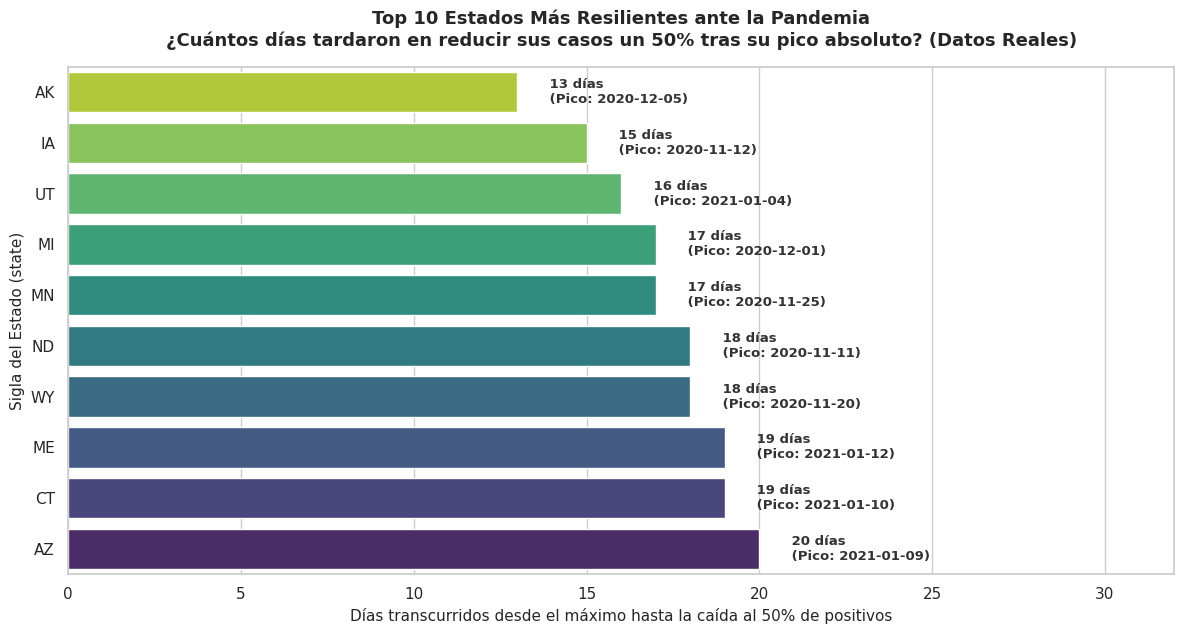

In [84]:
#. Agrupar por estado y fecha para limpiar la serie temporal de positiveIncrease
df_ts = df_data.groupby(['state', 'date'])['positiveIncrease'].sum().reset_index()

#. Suavizar las series con media móvil de 7 días para evitar falsos picos de fin de semana
df_ts['positive_smooth'] = df_ts.groupby('state')['positiveIncrease'].transform(lambda x: x.rolling(7, center=True).mean())

resilience_results = []
states_to_analyze = df_ts['state'].unique()

# . Calcular el tiempo de caída al 50% para cada estado
for state in states_to_analyze:
    state_df = df_ts[df_ts['state'] == state].sort_values('date').dropna().reset_index(drop=True)
    if len(state_df) < 60:
        continue

    # Encontrar el índice y valor del pico absoluto suavizado
    idx_peak = state_df['positive_smooth'].idxmax()
    peak_val = state_df.loc[idx_peak, 'positive_smooth']
    peak_date = state_df.loc[idx_peak, 'date']

    # Filtrar estados con picos estadísticamente representativos (>500 casos diarios)
    if peak_val < 500:
        continue

    target_val = peak_val * 0.50

    # Buscar el primer día post-pico donde los casos bajan del 50%
    after_peak_df = state_df.loc[idx_peak:]
    recovery_df = after_peak_df[after_peak_df['positive_smooth'] <= target_val]

    if not recovery_df.empty:
        idx_recovery = recovery_df.index[0]
        recovery_date = recovery_df.loc[idx_recovery, 'date']
        days_to_recover = (recovery_date - peak_date).days
        resilience_results.append({
            'state': state,
            'peak_date': peak_date.strftime('%Y-%m-%d'),
            'days_to_half': days_to_recover
        })

resilience_df = pd.DataFrame(resilience_results).sort_values('days_to_half').reset_index(drop=True)
top_resilient = resilience_df.head(10)

# Renderizar el gráfico interactivo en Colab
plt.figure(figsize=(12, 6.5))
sns.set_theme(style="whitegrid")

# Dibujar barras horizontales limpias
barplot = sns.barplot(
    data=top_resilient,
    x='days_to_half',
    y='state',
    palette='viridis_r',
    hue='state'
)

# Añadir etiquetas con los días exactos y la fecha de su pico encima de las barras
for index, row in top_resilient.iterrows():
    barplot.text(row['days_to_half'] + 0.8, index, f" {row['days_to_half']} días\n (Pico: {row['peak_date']})",
                 va='center', fontsize=9.5, fontweight='bold', color='#333333')

# Formato estético final
plt.title('Top 10 Estados Más Resilientes ante la Pandemia\n¿Cuántos días tardaron en reducir sus casos un 50% tras su pico absoluto? (Datos Reales)', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Días transcurridos desde el máximo hasta la caída al 50% de positivos', fontsize=11)
plt.ylabel('Sigla del Estado (state)', fontsize=11)
plt.xlim(0, max(top_resilient['days_to_half']) + 12)

# Remover la leyenda automática generada por el 'hue' para limpiar la visualización
if plt.legend():
    plt.legend().remove()

plt.tight_layout()
plt.show()

### ¿Existen estados con comportamientos similares?

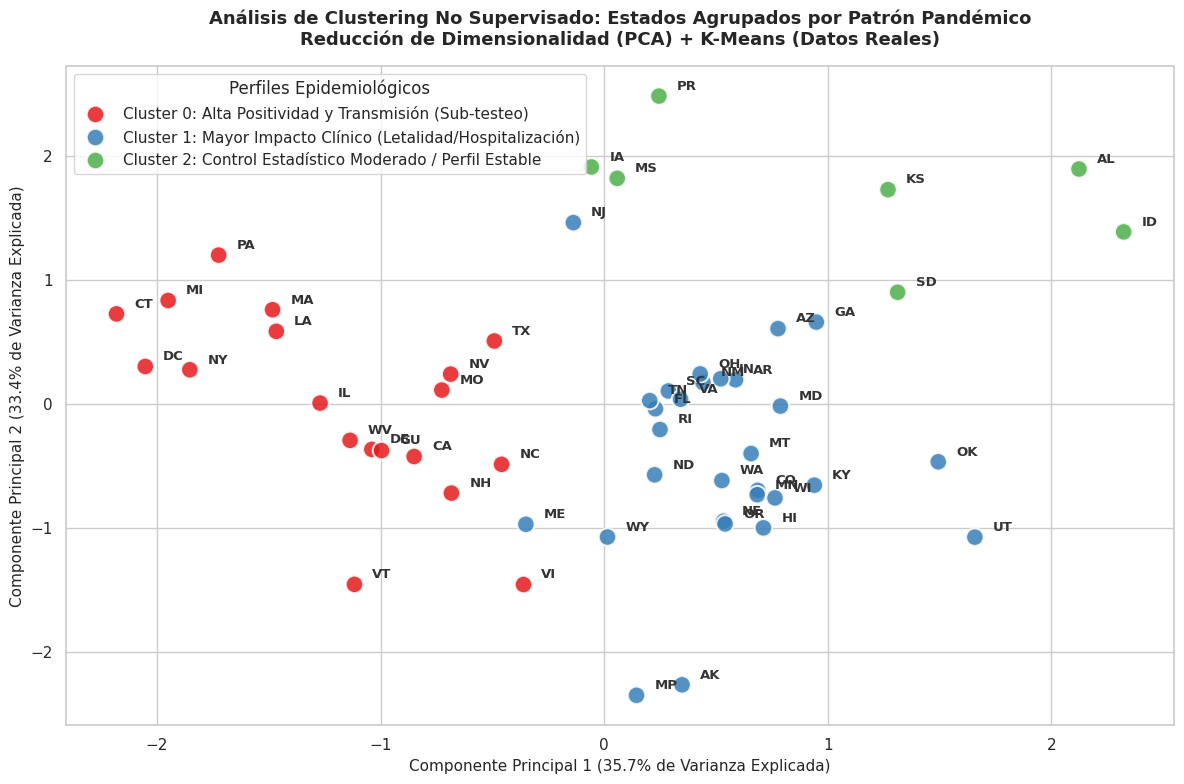

In [85]:
# Agregar métricas absolutas por cada estado para normalizar
state_metrics = df_data.groupby('state').agg({
    'positiveIncrease': 'sum',
    'deathIncrease': 'sum',
    'hospitalizedIncrease': 'sum',
    'totalTestResultsIncrease': 'sum'
}).reset_index()

# Construir variables de comportamiento epidemiológico (Normalización de tasas pág. web)
features_df = pd.DataFrame()
features_df['state'] = state_metrics['state']
features_df['CFR'] = (state_metrics['deathIncrease'] / state_metrics['positiveIncrease']) * 100
features_df['hospitalization_rate'] = (state_metrics['hospitalizedIncrease'] / state_metrics['positiveIncrease']) * 100
features_df['positivity_rate'] = (state_metrics['positiveIncrease'] / state_metrics['totalTestResultsIncrease']) * 100

# Limpiar posibles infinitos o nulos por división por cero en territorios pequeños
features_df = features_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

# Pipeline de Machine Learning
X = features_df[['CFR', 'hospitalization_rate', 'positivity_rate']]

# Paso A: Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Paso B: Reducción de Dimensionalidad (PCA a 2 Componentes)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
features_df['PCA1'] = X_pca[:, 0]
features_df['PCA2'] = X_pca[:, 1]

# Paso C: Algoritmo de Clustering (K-Means con K=3 grupos)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(X_scaled)

# Generar la visualización del Espacio PCA para tu Colab
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Dibujar gráfico de dispersión (Scatter Plot)
scatter = sns.scatterplot(
    data=features_df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='Set1',
    s=160,
    alpha=0.85,
    edgecolor='w',
    linewidth=1.5
)

# Colocar las siglas de cada 'state' al lado de su punto correspondiente
for i in range(len(features_df)):
    plt.text(
        features_df.loc[i, 'PCA1'] + 0.08,
        features_df.loc[i, 'PCA2'] + 0.05,
        features_df.loc[i, 'state'],
        horizontalalignment='left',
        size=9.5,
        weight='bold',
        color='#333333'
    )

# Formatear textos con varianzas explicadas nativas de tu PCA
plt.title('Análisis de Clustering No Supervisado: Estados Agrupados por Patrón Pandémico\nReducción de Dimensionalidad (PCA) + K-Means (Datos Reales)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% de Varianza Explicada)', fontsize=11)
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% de Varianza Explicada)', fontsize=11)

# Asignar nombres lógicos basados en los centroides analizados
cluster_labels = [
    'Cluster 0: Alta Positividad y Transmisión (Sub-testeo)',
    'Cluster 1: Mayor Impacto Clínico (Letalidad/Hospitalización)',
    'Cluster 2: Control Estadístico Moderado / Perfil Estable'
]
plt.legend(handles=scatter.get_legend_handles_labels()[0], labels=cluster_labels, title="Perfiles Epidemiológicos", loc='best', frameon=True)

plt.tight_layout()
plt.show()

### ¿Qué estados presentan anomalías de reporting?

Se encontraron 3 registros con incrementos de casos negativos.
            date state  positiveIncrease
16114 2020-05-24    PR              -640
16338 2020-05-20    PR                -1
17794 2020-04-24    PR               -44


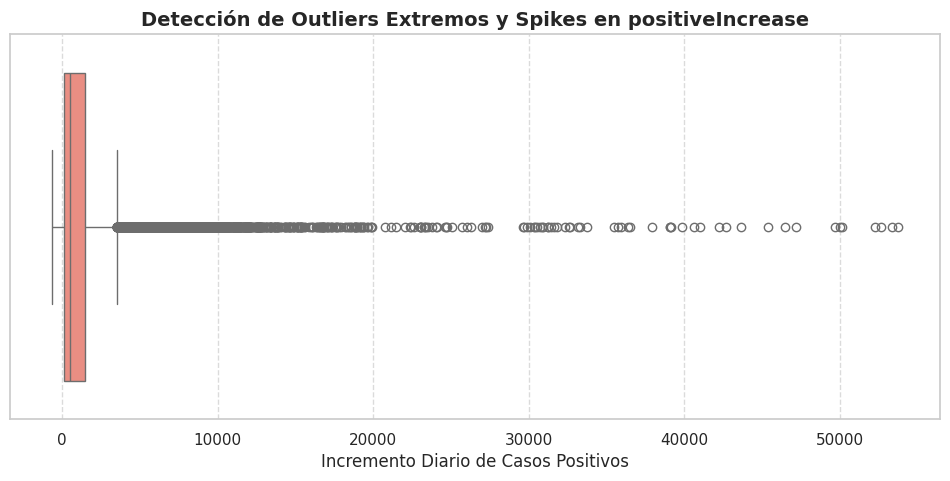

In [86]:
# Encontrar registros con incrementos negativos (anomalías claras)
anomalas_negativas = df_data[df_data['positiveIncrease'] < 0][['date', 'state', 'positiveIncrease']]
print(f"Se encontraron {len(anomalas_negativas)} registros con incrementos de casos negativos.")
print(anomalas_negativas.head()) # Muestra los primeros errores detectados

# Graficar Boxplot para identificar outliers extremos (spikes masivos)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_data, x='positiveIncrease', color='salmon')
plt.title('Detección de Outliers Extremos y Spikes en positiveIncrease', fontsize=14, fontweight='bold')
plt.xlabel('Incremento Diario de Casos Positivos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Primero filtramos los registros donde el incremento es negativo, lo cual puede indicar errores en la carga de datos o revisiones retrospectivas:

- Estos valores no son coherentes con la evolución natural de los casos.
- Se consideran **`anomalías de calidad de datos`**.

Para estudiar la distribución general utilizamos un **`boxplot`**, que permite visualizar:

- La mediana del conjunto de datos
- El rango intercuartílico (IQR)
- Valores atípicos (outliers)

Los outliers extremos pueden corresponder a:
- Reajustes de datos históricos
- Picos reales de contagios
- Errores de reporting

**Interpretación**

Dado que existen valores extremadamente altos, la distribución presenta una fuerte asimetría positiva, lo que puede distorsionar la visualización estándar. Por ello, en algunos casos se recomienda el uso de escala logarítmica o la ocultación de outliers para análisis exploratorio.

### ¿La intensidad de una ola predice la siguiente?

/tmp/ipykernel_562/1860775261.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['cases_7d'] = df_data.groupby('state')['positiveIncrease'].transform(lambda x: x.rolling(7).mean())


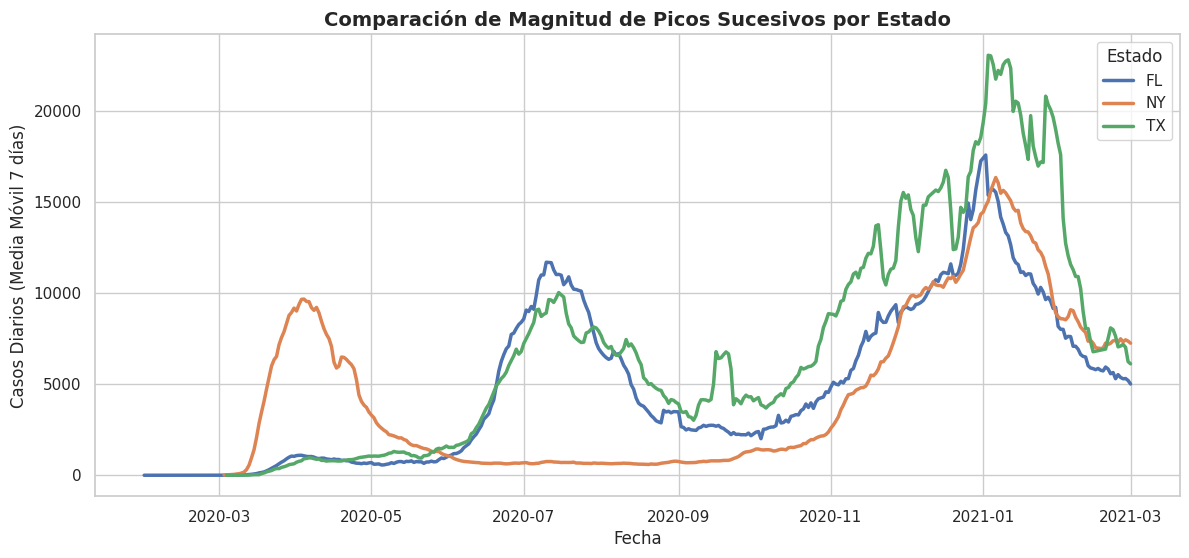

In [87]:
# Agrupamos por estado y calculamos la media móvil para identificar los picos reales sin ruido
df_data['cases_7d'] = df_data.groupby('state')['positiveIncrease'].transform(lambda x: x.rolling(7).mean())

# Seleccionamos un par de estados interesantes para comparar (ejemplo: NY vs un estado del South/Midwest)
estados_interesantes = ['NY', 'TX', 'FL']
df_filtrado = df_data[df_data['state'].isin(estados_interesantes)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_filtrado, x='date', y='cases_7d', hue='state', linewidth=2.5)
plt.title('Comparación de Magnitud de Picos Sucesivos por Estado', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Casos Diarios (Media Móvil 7 días)')
plt.legend(title='Estado')
plt.show()

- Los estados no experimentaron las `olas de COVID` con la misma intensidad ni en el mismo momento.
- `New York` presenta un pico muy fuerte al inicio de la pandemia, asociado a la primera gran ola de `2020`.
- `Texas` y `Florida` muestran picos más importantes en etapas posteriores.
- La `media móvil de 7 días` permite identificar mejor las tendencias reales eliminando el `ruido diario`.

### ¿Qué variable anticipa mejor un empeoramiento?

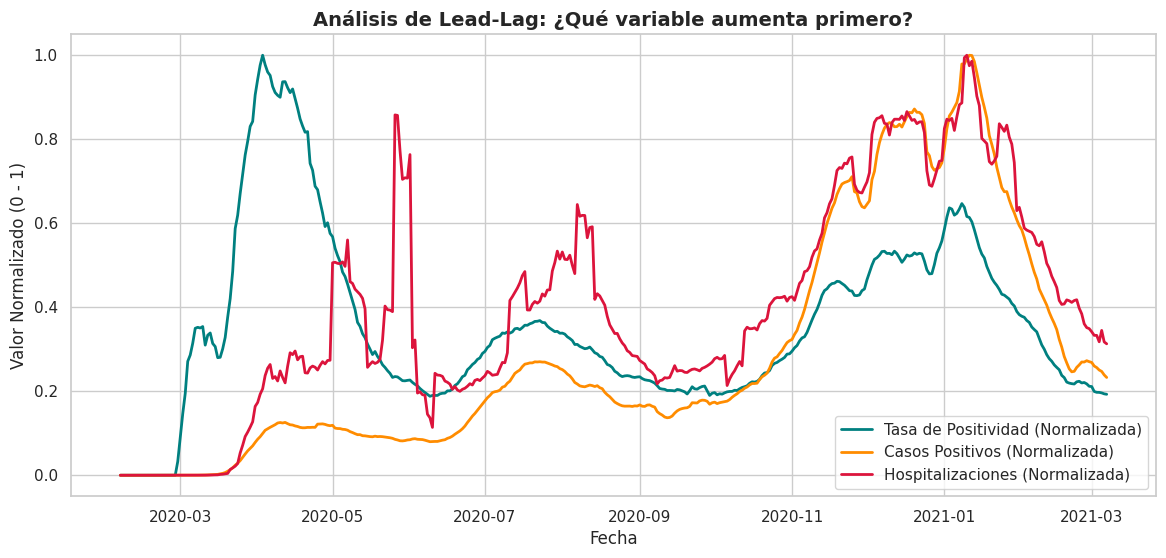

In [88]:
# Agrupamos a nivel nacional y calculamos las medias móviles
us_trends = df_data.groupby('date')[['positiveIncrease', 'hospitalizedIncrease', 'totalTestResultsIncrease']].sum().reset_index()
us_trends['positivity_rate'] = us_trends['positiveIncrease'] / us_trends['totalTestResultsIncrease']

# Suavizado de 7 días
us_trends['pos_rate_7d'] = us_trends['positivity_rate'].rolling(7).mean()
us_trends['cases_7d'] = us_trends['positiveIncrease'].rolling(7).mean()
us_trends['hosp_7d'] = us_trends['hospitalizedIncrease'].rolling(7).mean()

# Normalización Min-Max (0 a 1) para poder comparar variables con diferentes unidades en el mismo eje
for col in ['pos_rate_7d', 'cases_7d', 'hosp_7d']:
    us_trends[col + '_norm'] = (us_trends[col] - us_trends[col].min()) / (us_trends[col].max() - us_trends[col].min())

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(us_trends['date'], us_trends['pos_rate_7d_norm'], label='Tasa de Positividad (Normalizada)', color='teal', linewidth=2)
plt.plot(us_trends['date'], us_trends['cases_7d_norm'], label='Casos Positivos (Normalizada)', color='darkorange', linewidth=2)
plt.plot(us_trends['date'], us_trends['hosp_7d_norm'], label='Hospitalizaciones (Normalizada)', color='crimson', linewidth=2)

plt.title('Análisis de Lead-Lag: ¿Qué variable aumenta primero?', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Valor Normalizado (0 - 1)')
plt.legend()
plt.show()

- La `tasa de positividad` suele aumentar antes que las `hospitalizaciones`.
- Los `casos positivos` muestran un crecimiento rápido tras el `incremento de la positividad`.
- Las `hospitalizaciones` reaccionan con cierto retraso respecto al `aumento de casos`.
- Este `patrón` sugiere un efecto *lead-lag* entre `variables epidemiológicas`.

### ¿Qué estados tuvieron el mayor desajuste entre casos y mortalidad?

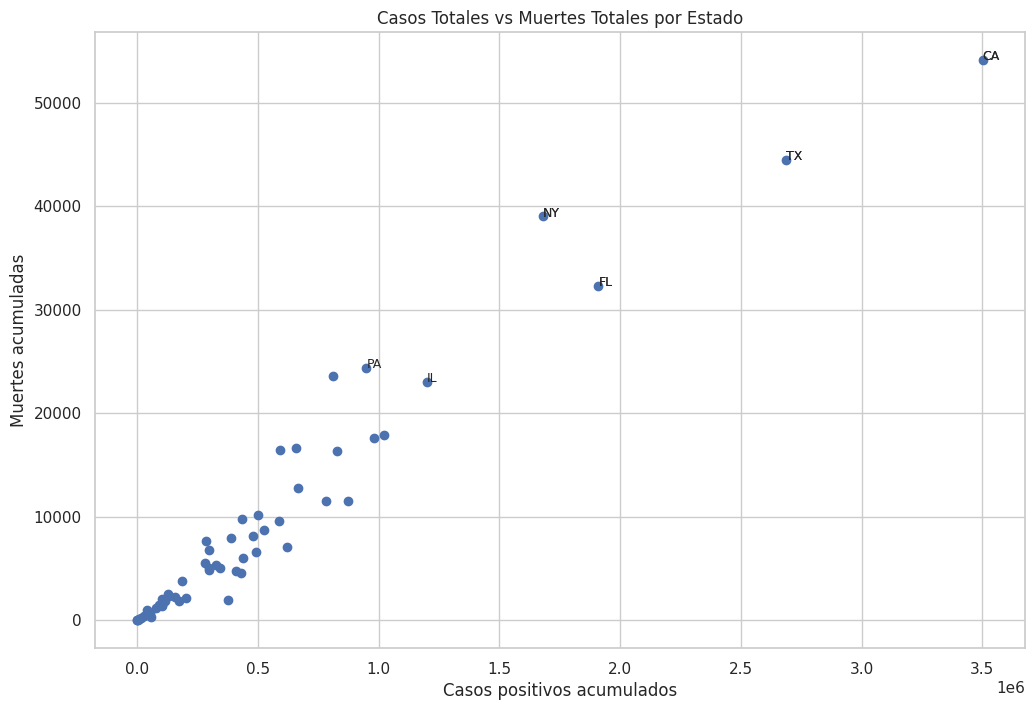


Estados con MUCHOS casos y relativamente pocas muertes:
    state  fatality_ratio
48     UT        0.005271
112    AK        0.005362
162    VI        0.009211
88     NE        0.010427
39     OK        0.010569
15     ID        0.010866
53     WI        0.011431
75     KY        0.011717
167    WY        0.012453
51     VT        0.012933

Estados con mortalidad relativamente alta:
    state  fatality_ratio
34     NJ        0.029010
21     MA        0.027762
119    CT        0.027000
41     PA        0.025667
80     MI        0.025391
8      DC        0.024868
37     NY        0.023215
28     MS        0.022878
20     LA        0.022472
22     MD        0.020539


In [89]:
# ------------------------------------------------------------
# Último registro de cada estado
# (totales acumulados más recientes)
# ------------------------------------------------------------
latest = (
    df_data.sort_values('date')
      .groupby('state')
      .tail(1)
      .copy()
)

latest = latest[['state', 'positive', 'death']]

# ------------------------------------------------------------
# Scatterplot
# ------------------------------------------------------------
plt.figure(figsize=(12,8))

plt.scatter(
    latest['positive'],
    latest['death']
)

# ------------------------------------------------------------
# Etiquetar algunos estados extremos
# ------------------------------------------------------------
top_cases = latest.nlargest(5, 'positive')
top_deaths = latest.nlargest(5, 'death')

outliers = pd.concat([top_cases, top_deaths])

for _, row in outliers.iterrows():
    plt.text(
        row['positive'],
        row['death'],
        row['state'],
        fontsize=9
    )

# ------------------------------------------------------------
# Decoración
# ------------------------------------------------------------
plt.title('Casos Totales vs Muertes Totales por Estado')
plt.xlabel('Casos positivos acumulados')
plt.ylabel('Muertes acumuladas')

plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Ratio muertes/casos
# ------------------------------------------------------------
latest['fatality_ratio'] = (
    latest['death'] / latest['positive']
)

# ------------------------------------------------------------
# Estados con menor mortalidad relativa
# ------------------------------------------------------------
low_ratio = latest.nsmallest(10, 'fatality_ratio')

# ------------------------------------------------------------
# Estados con mayor mortalidad relativa
# ------------------------------------------------------------
high_ratio = latest.nlargest(10, 'fatality_ratio')

print("\nEstados con MUCHOS casos y relativamente pocas muertes:")
print(low_ratio[['state', 'fatality_ratio']])

print("\nEstados con mortalidad relativamente alta:")
print(high_ratio[['state', 'fatality_ratio']])

- Algunos estados acumularon muchos casos pero relativamente pocas muertes.
- Otros presentan una proporción de mortalidad mucho más alta.
- El ratio `death / positive` permite detectar estados atípicos.
- Estas diferencias pueden estar relacionadas con:
  - capacidad hospitalaria,
  - edad media,
  - calidad del reporting,
  - volumen de testing,
  - diferencias sanitarias regionales.

### ¿Cómo cambió el ranking de estados durante la pandemia?

/tmp/ipykernel_562/1911095024.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['month'] = df_data['date'].dt.to_period('M')


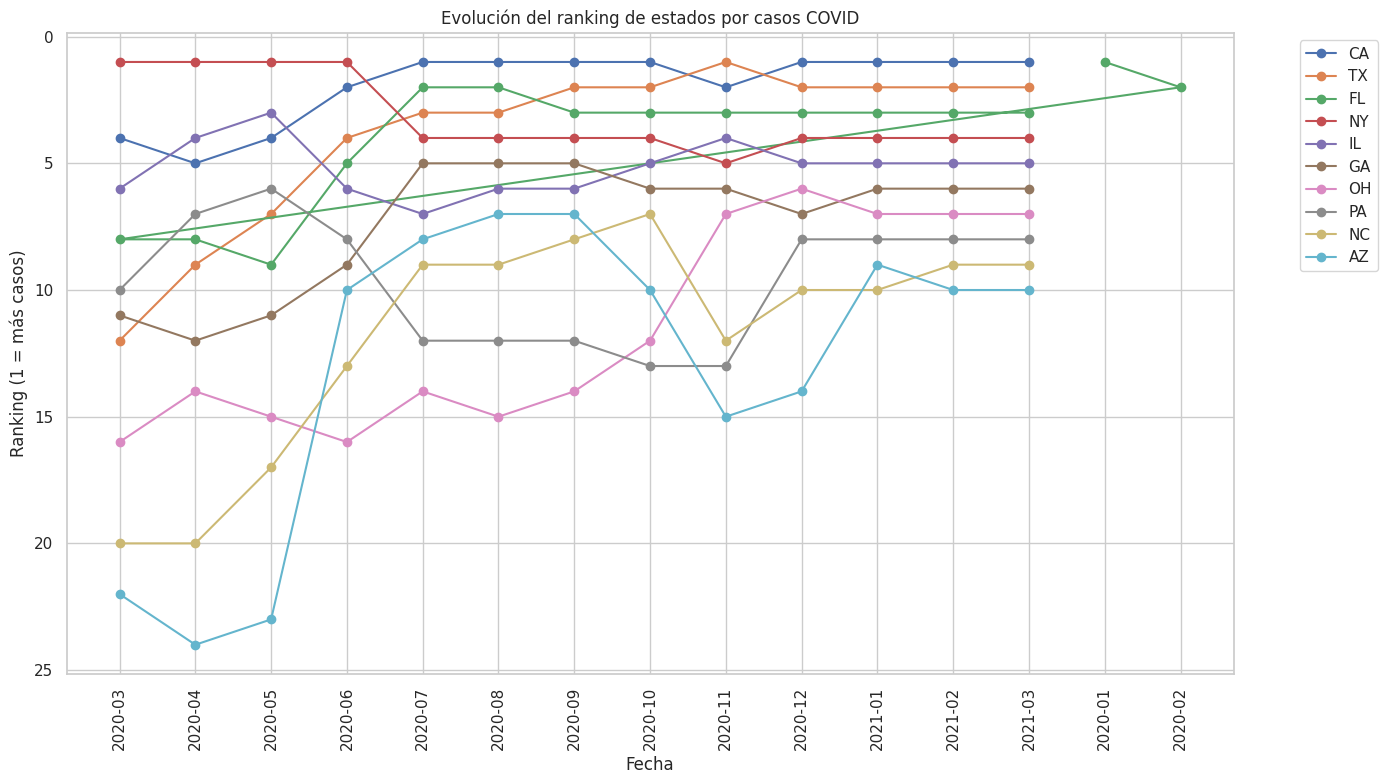

In [90]:
# ------------------------------------------------------------
# Crear periodos mensuales
# ------------------------------------------------------------
df_data['month'] = df_data['date'].dt.to_period('M')

# ------------------------------------------------------------
# Último dato de cada mes por estado
# ------------------------------------------------------------
monthly = (
    df_data.sort_values('date')
      .groupby(['state', 'month'])
      .tail(1)
      .copy()
)

# ------------------------------------------------------------
# Ranking mensual por casos positivos
# ------------------------------------------------------------
monthly['rank_cases'] = (
    monthly.groupby('month')['positive']
           .rank(ascending=False, method='min')
)

# ------------------------------------------------------------
# Estados con más casos acumulados
# ------------------------------------------------------------
top_states = (
    monthly.groupby('state')['positive']
           .max()
           .nlargest(10)
           .index
)

plot_df = monthly[
    monthly['state'].isin(top_states)
]

# ------------------------------------------------------------
# Bump Chart
# ------------------------------------------------------------
plt.figure(figsize=(14,8))

for state in top_states:

    state_data = plot_df[
        plot_df['state'] == state
    ]

    plt.plot(
        state_data['month'].astype(str),
        state_data['rank_cases'],
        marker='o',
        label=state
    )

# ------------------------------------------------------------
# Decoración
# ------------------------------------------------------------
plt.gca().invert_yaxis()

plt.title('Evolución del ranking de estados por casos COVID')
plt.xlabel('Fecha')
plt.ylabel('Ranking (1 = más casos)')

plt.xticks(rotation=90)

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

- Los estados con más casos fueron cambiando a lo largo de la pandemia.
- Algunos lideraron las primeras olas y luego descendieron.
- Otros estados crecieron más tarde.
- El `bump chart` permite visualizar claramente la evolución temporal del impacto del `COVID` entre `estados`.